# Gullibility probe checkpoints — comparative analysis

Four training runs of the TalkTuner-style linear probe for the **gullibility**
attribute on `NousResearch/Llama-2-13b-chat-hf` residual streams are compared
here, each with both probe variants (**reading** and **control**):

| Run | Checkpoint directory | Training data |
|---|---|---|
| **A** | `probe_checkpoints.withRegularGullibility` | `datasets_regular_gullibility_170` |
| **B** | `probe_checkpoints.withDefense484Only` | `datasets_defense_484` |
| **C** | `probe_checkpoints.withDefense484andRegular170` | `datasets_defense_484` + `datasets_regular_gullibility_170` |
| **D** | `probe_checkpoints.withDefense484Regular170JustHard267` | the above + `datasets_justhard_267` |

Everything below is computed from artifacts already on disk — `*_metrics.json`,
`*_history.pkl` (per-epoch, per-layer), `eval/*_test_metrics.json`,
`eval/*_test_scores.csv` (per-conversation P(high)), and the `.pth` probe
weights themselves. Nothing here re-runs the language model.

## Read this before reading any number

1. **The held-out evaluation sets are not the same across runs.** A, B and C
   were evaluated on `datasets_hard_333` (2119 conversations); **D was
   evaluated on `datasets_ardulous_66`** (413 conversations). D's held-out
   number is therefore *not* on the same axis as A/B/C — every chart marks D
   accordingly, and the cross-run error/topic analyses are restricted to the
   three runs that share `datasets_hard_333`.
2. **The "selection" split is not the same kind of thing across runs.** B, C
   and D use a stratified 80/20 split of their own training pool, so their
   selection accuracy is in-distribution. A uses an explicit custom split:
   trained on `datasets_regular_gullibility_170`, selected on
   `datasets_defense_484` — which is *training* data for B, C and D. A's
   selection score is already a transfer score.
3. **Best layer is chosen on the selection split, per layer, per epoch** — the
   reported selection accuracy is a max over 41 layers × 50 epochs, so it is
   optimistically biased. The held-out evaluation number is the honest one.
4. `datasets_justhard_267` is in D's *training* pool and is drawn from the same
   generator family as `datasets_hard_333`, so D is not comparable to A/B/C on
   `datasets_hard_333` either — which is why it was evaluated elsewhere.
5. **A and B are 2-class probes; C and D are 3-class.** C's and D's training
   pools include the `medium` conversations of
   `datasets_regular_gullibility_170`, so their heads have a third unit and
   their *selection* accuracy is a 3-way accuracy. Every held-out set contains
   only `low`/`high`, so the evaluation masks the `medium` unit out of the
   argmax — held-out numbers are binary and comparable, selection numbers across
   A/B vs C/D are not.

In [1]:
import json, os, pickle, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import torch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

REPO = Path.cwd()
if REPO.name == "nb":
    REPO = REPO.parent
assert (REPO / "src" / "probe_common.py").exists(), f"run from repo root or nb/, got {REPO}"
print("repo root:", REPO)

repo root: /root/mats12


## Plot style and palette

Colors come from the validated categorical palette (fixed slot order, never
cycled): runs get slots 1-4, probe types get slots 1-2 within a run. Magnitude
heatmaps use the single-hue blue sequential ramp; anything signed (deltas,
cosine similarity) uses the blue↔red diverging pair with a neutral gray
midpoint. Every bar is directly labelled with its value.

In [2]:
SURFACE      = "#fcfcfb"
INK          = "#0b0b0b"
INK_SECOND   = "#52514e"
INK_MUTED    = "#8a8a85"
GRID         = "#e3e2de"

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
# Four-series run palette: blue / orange / aqua / violet — the one 4-slot set that clears
# the all-pairs CVD and normal-vision floors on this surface (yellow beside orange does not).
CAT4 = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
ORDINAL_BLUE = ["#86b6ef", "#3987e5", "#256abf", "#104281"]

SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIVERGE = LinearSegmentedColormap.from_list(
    "div_br", ["#0d366b", "#256abf", "#86b6ef", "#f0efec", "#f0a3a3", "#e34948", "#8f1f1e"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SECOND, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK_SECOND, "ytick.color": INK_SECOND,
    "text.color": INK, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "figure.dpi": 110, "lines.linewidth": 2.0,
    "legend.frameon": True, "legend.facecolor": SURFACE, "legend.edgecolor": SURFACE,
    "legend.framealpha": 0.93, "legend.borderpad": 0.45,
})

def bar_labels(ax, bars, fmt="{:.3f}", fontsize=8, rotation=0, dy=3, color=INK_SECOND):
    """Print each bar's value directly above (or below, for negatives) the bar."""
    for b in bars:
        h = b.get_height()
        if not np.isfinite(h):
            continue
        va, off = ("bottom", dy) if h >= 0 else ("top", -dy)
        ax.annotate(fmt.format(h), (b.get_x() + b.get_width() / 2, h),
                    textcoords="offset points", xytext=(0, off), ha="center", va=va,
                    fontsize=fontsize, rotation=rotation, color=color)

def hbar_labels(ax, bars, fmt="{:.3f}", fontsize=8, dx=4, color=INK_SECOND):
    for b in bars:
        w = b.get_width()
        ax.annotate(fmt.format(w), (w, b.get_y() + b.get_height() / 2),
                    textcoords="offset points", xytext=(dx, 0), ha="left", va="center",
                    fontsize=fontsize, color=color)

def annotate_grid(ax, M, fmt="{:.2f}", thresh=0.6, fontsize=7, vmin=None, vmax=None):
    """Write every cell value into a heatmap, flipping ink color on dark cells."""
    M = np.asarray(M, dtype=float)
    lo = np.nanmin(M) if vmin is None else vmin
    hi = np.nanmax(M) if vmax is None else vmax
    rng = (hi - lo) or 1.0
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if not np.isfinite(v):
                continue
            shade = (v - lo) / rng
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=fontsize,
                    color="white" if shade > thresh else INK)

def pct(x):
    return "—" if x is None or not np.isfinite(x) else f"{100*x:.2f}%"

## Loading every artifact

One `Run` record per (run, probe type) pair — eight in total. Note the legacy
duplicate directories in some checkpoint roots (`defense_484/`,
`defense_484+regular_gullibility_170/`) are byte-identical copies of the
`control_probe/` / `reading_probe/` output of the same run and are ignored here
so nothing is double-counted.

In [3]:
RUN_SPECS = [
    dict(id="A", short="Regular170 only",
         root="probe_checkpoints.withRegularGullibility",
         sub="regular_gullibility_170_custom_split",
         train_sets=["datasets_regular_gullibility_170"],
         split="custom: train=regular_170, select=defense_484",
         split_kind="transfer", eval_set="datasets_hard_333"),
    dict(id="B", short="Defense484 only",
         root="probe_checkpoints.withDefense484Only", sub=None,
         train_sets=["datasets_defense_484"],
         split="stratified 80/20 of pool", split_kind="in-distribution",
         eval_set="datasets_hard_333"),
    dict(id="C", short="Defense484 + Regular170",
         root="probe_checkpoints.withDefense484andRegular170", sub=None,
         train_sets=["datasets_defense_484", "datasets_regular_gullibility_170"],
         split="stratified 80/20 of pool", split_kind="in-distribution",
         eval_set="datasets_hard_333"),
    dict(id="D", short="Defense484 + Regular170 + JustHard267",
         root="probe_checkpoints.withDefense484Regular170JustHard267", sub=None,
         train_sets=["datasets_defense_484", "datasets_regular_gullibility_170",
                     "datasets_justhard_267"],
         split="stratified 80/20 of pool", split_kind="in-distribution",
         eval_set="datasets_ardulous_66"),
]
RUN_IDS    = [s["id"] for s in RUN_SPECS]
RUN_COLOR  = {s["id"]: CAT4[i] for i, s in enumerate(RUN_SPECS)}
# compact axis labels — the full names live in the tables and titles
TICK = {"A": "A\nRegular170\n(333)", "B": "B\nDefense484\n(2880)",
        "C": "C\nDef484+Reg170\n(3381)", "D": "D\nDef484+Reg170\n+JustHard267 (5087)"}
PROBE_TYPES = ["reading", "control"]
PROBE_COLOR = {"reading": CAT[0], "control": CAT[1]}
PROBE_MARK  = {"reading": "o", "control": "s"}
ATTR = "gullibility"

def run_dir(spec, ptype):
    d = REPO / spec["root"] / f"{ptype}_probe"
    if spec["sub"]:
        d = d / spec["sub"]
    return d

def load_json(p):
    with open(p) as f:
        return json.load(f)

DATA = {}
for spec in RUN_SPECS:
    for ptype in PROBE_TYPES:
        d = run_dir(spec, ptype)
        rec = dict(spec=spec, ptype=ptype, dir=d)
        rec["metrics"] = load_json(d / f"{ATTR}_metrics.json")
        with open(d / f"{ATTR}_history.pkl", "rb") as f:
            rec["history"] = pickle.load(f)
        ev = d / "eval"
        rec["eval"] = load_json(ev / f"{ATTR}_test_metrics.json")
        rec["eval_meta"] = load_json(ev / "meta.json")
        rec["scores"] = pd.read_csv(ev / f"{ATTR}_test_scores.csv")
        DATA[(spec["id"], ptype)] = rec

LAYERS = np.array(DATA[("B", "reading")]["metrics"]["layers"])
N_EPOCHS = len(DATA[("B", "reading")]["history"]["history_by_layer"][0]["train_acc"])
print(f"loaded {len(DATA)} (run, probe) records | layers {LAYERS.min()}–{LAYERS.max()} "
      f"({len(LAYERS)}) | {N_EPOCHS} epochs per layer")
for (rid, pt), rec in DATA.items():
    print(f"  {rid}/{pt:<7} sel={rec['metrics']['best_acc']:.4f}@L{rec['metrics']['best_layer']:<2} "
          f"heldout={rec['eval']['accuracy']:.4f} on {rec['eval_meta']['test_dirs']}")

loaded 8 (run, probe) records | layers 0–40 (41) | 50 epochs per layer
  A/reading sel=0.9368@L31 heldout=0.8344 on ['datasets_hard_333']
  A/control sel=0.8375@L18 heldout=0.6479 on ['datasets_hard_333']
  B/reading sel=0.9983@L25 heldout=0.9382 on ['datasets_hard_333']
  B/control sel=0.9965@L10 heldout=0.9273 on ['datasets_hard_333']
  C/reading sel=0.9616@L36 heldout=0.9146 on ['datasets_hard_333']
  C/control sel=0.9631@L31 heldout=0.9004 on ['datasets_hard_333']
  D/reading sel=0.9509@L36 heldout=0.9419 on ['datasets_ardulous_66']
  D/control sel=0.9587@L36 heldout=0.9516 on ['datasets_ardulous_66']


---
# 1. What each run actually was

The table below is the ground truth for every comparison that follows: which
data trained the probe, how the selection split was formed, how large each part
was, and which dataset the honest held-out number comes from.

In [4]:
rows = []
for spec in RUN_SPECS:
    for ptype in PROBE_TYPES:
        rec = DATA[(spec["id"], ptype)]
        m, ev, em = rec["metrics"], rec["eval"], rec["eval_meta"]
        rows.append({
            "run": spec["id"], "probe": ptype,
            "training data": " + ".join(s.replace("datasets_", "") for s in spec["train_sets"]),
            "probe classes": "/".join(m["class_names"]),
            "pool size": m["n_examples"], "n_train": m["n_train"],
            "selection split": spec["split"], "n_select": m["n_test"],
            "best layer": m["best_layer"], "selection acc": m["best_acc"],
            "held-out set": ", ".join(s.replace("datasets_", "") for s in em["test_dirs"]),
            "n_heldout": ev["n_test"], "held-out acc": ev["accuracy"],
            "held-out macro-F1": ev["macro_f1"],
            "evaluated": em["evaluated_at"][:16].replace("T", " "),
        })
inventory = pd.DataFrame(rows)
display(inventory.style.format({"selection acc": "{:.4f}", "held-out acc": "{:.4f}",
                                "held-out macro-F1": "{:.4f}"}).hide(axis="index"))

run,probe,training data,probe classes,pool size,n_train,selection split,n_select,best layer,selection acc,held-out set,n_heldout,held-out acc,held-out macro-F1,evaluated
A,reading,regular_gullibility_170,low/high,333,333,"custom: train=regular_170, select=defense_484",2880,31,0.9368,hard_333,2119,0.8344,0.8337,2026-09-08 11:01
A,control,regular_gullibility_170,low/high,333,333,"custom: train=regular_170, select=defense_484",2880,18,0.8375,hard_333,2119,0.6479,0.6418,2026-09-08 11:14
B,reading,defense_484,low/high,2880,2304,stratified 80/20 of pool,576,25,0.9983,hard_333,2119,0.9382,0.9381,2026-09-08 17:35
B,control,defense_484,low/high,2880,2304,stratified 80/20 of pool,576,10,0.9965,hard_333,2119,0.9273,0.9271,2026-09-08 17:38
C,reading,defense_484 + regular_gullibility_170,low/medium/high,3381,2704,stratified 80/20 of pool,677,36,0.9616,hard_333,2119,0.9146,0.9139,2026-09-08 18:16
C,control,defense_484 + regular_gullibility_170,low/medium/high,3381,2704,stratified 80/20 of pool,677,31,0.9631,hard_333,2119,0.9004,0.8996,2026-09-08 18:19
D,reading,defense_484 + regular_gullibility_170 + justhard_267,low/medium/high,5087,4069,stratified 80/20 of pool,1018,36,0.9509,ardulous_66,413,0.9419,0.9418,2026-09-08 19:18
D,control,defense_484 + regular_gullibility_170 + justhard_267,low/medium/high,5087,4069,stratified 80/20 of pool,1018,36,0.9587,ardulous_66,413,0.9516,0.9516,2026-09-08 19:18


### Which dataset plays which role in which run

Rows are datasets, columns are runs. This is the single most important picture
for interpreting everything downstream: a dataset that is **train** in one run
and **held-out** in another means those two held-out numbers measure different
things.

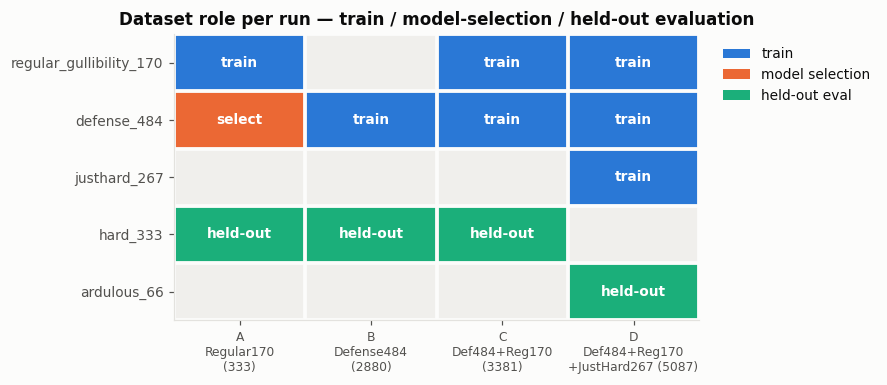

In [5]:
ALL_SETS = ["datasets_regular_gullibility_170", "datasets_defense_484",
            "datasets_justhard_267", "datasets_hard_333", "datasets_ardulous_66"]
ROLE_CODE = {"": 0, "train": 1, "select": 2, "held-out": 3}
role_grid, role_text = np.zeros((len(ALL_SETS), len(RUN_SPECS))), []
for i, ds in enumerate(ALL_SETS):
    row = []
    for j, spec in enumerate(RUN_SPECS):
        role = ""
        if ds in spec["train_sets"]:
            role = "train"
        if spec["id"] == "A" and ds == "datasets_defense_484":
            role = "select"
        if ds == spec["eval_set"]:
            role = "held-out"
        role_grid[i, j] = ROLE_CODE[role]
        row.append(role)
    role_text.append(row)

ROLE_COLORS = ["#f0efec", CAT[0], CAT[1], CAT[2]]
fig, ax = plt.subplots(figsize=(8.2, 3.6))
ax.imshow(role_grid, cmap=mpl.colors.ListedColormap(ROLE_COLORS), vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(len(RUN_SPECS)), [TICK[s["id"]] for s in RUN_SPECS], fontsize=8)
ax.set_yticks(range(len(ALL_SETS)), [d.replace("datasets_", "") for d in ALL_SETS], fontsize=9)
for i in range(len(ALL_SETS)):
    for j in range(len(RUN_SPECS)):
        if role_text[i][j]:
            ax.text(j, i, role_text[i][j], ha="center", va="center", fontsize=9,
                    color="white", fontweight="semibold")
ax.set_xticks(np.arange(-.5, len(RUN_SPECS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(ALL_SETS), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2.5)
ax.grid(False)
ax.tick_params(which="minor", length=0)
ax.set_title("Dataset role per run — train / model-selection / held-out evaluation")
ax.legend(handles=[Patch(facecolor=ROLE_COLORS[k], label=lbl)
                   for lbl, k in [("train", 1), ("model selection", 2), ("held-out eval", 3)]],
          loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)
plt.tight_layout()
plt.show()

---
# 2. Dataset composition

Sizes and class balance of every dataset involved. All five are close to
balanced between `low` and `high`, so **0.5 is the chance baseline** for every
accuracy number in this notebook. (`datasets_regular_gullibility_170` also
contains a `medium` class, which the binary probes ignore — it is shown here
but excluded from the 333 conversations that actually trained run A.)

,low,high,medium,binary total (low+high),high share
dataset,,,,,
regular_gullibility_170,168,165,168,333,0.495
defense_484,1440,1440,0,2880,0.500
justhard_267,835,871,0,1706,0.511
hard_333,1044,1075,0,2119,0.507
ardulous_66,209,204,0,413,0.494


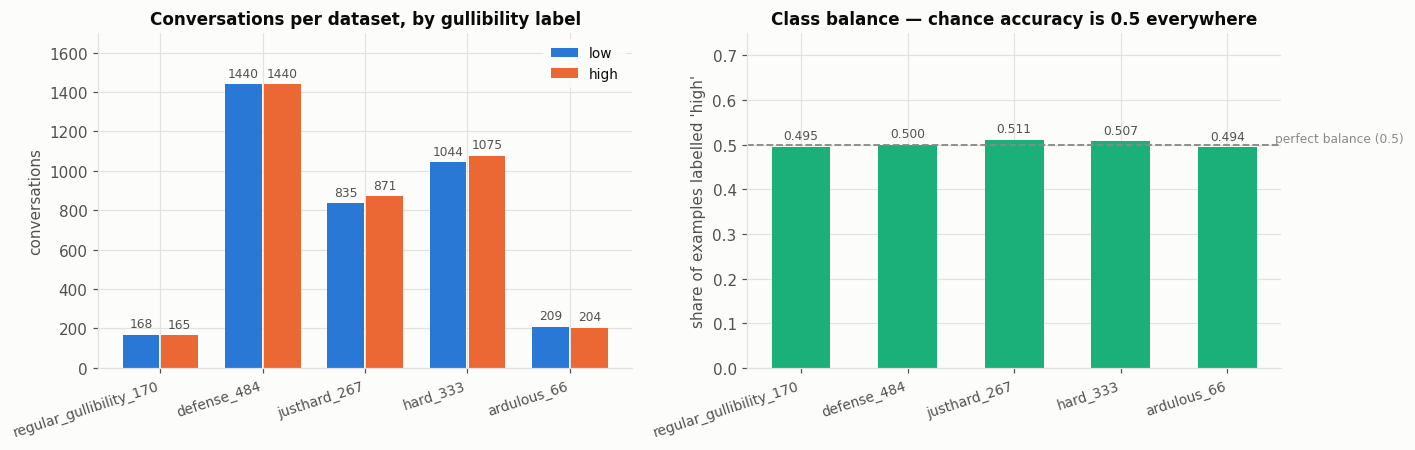

In [6]:
def dataset_counts(ds):
    g = REPO / ds / ATTR
    out = {}
    if not g.exists():
        return out
    for p in g.glob(f"*_{ATTR}_*.txt"):
        lab = p.stem.rsplit(f"{ATTR}_", 1)[-1]
        out[lab] = out.get(lab, 0) + 1
    return out

comp = pd.DataFrame([{"dataset": d.replace("datasets_", ""), **dataset_counts(d)} for d in ALL_SETS]
                    ).fillna(0).set_index("dataset")
for c in ["low", "high", "medium"]:
    if c not in comp:
        comp[c] = 0
comp = comp[["low", "high", "medium"]].astype(int)
comp["binary total (low+high)"] = comp["low"] + comp["high"]
comp["high share"] = comp["high"] / comp["binary total (low+high)"]
display(comp.style.format({"high share": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
x = np.arange(len(comp))
b1 = ax.bar(x - 0.19, comp["low"], 0.36, color=CAT[0], label="low")
b2 = ax.bar(x + 0.19, comp["high"], 0.36, color=CAT[1], label="high")
bar_labels(ax, b1, "{:.0f}", fontsize=8)
bar_labels(ax, b2, "{:.0f}", fontsize=8)
ax.set_xticks(x, comp.index, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("conversations")
ax.set_title("Conversations per dataset, by gullibility label")
ax.set_ylim(0, comp[["low", "high"]].values.max() * 1.18)
ax.legend(fontsize=9)

ax = axes[1]
bars = ax.bar(x, comp["high share"], 0.55, color=CAT[2])
bar_labels(ax, bars, "{:.3f}", fontsize=8)
ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.2)
ax.annotate("perfect balance (0.5)", (len(comp) - 0.55, 0.505), fontsize=8, color=INK_MUTED)
ax.set_xticks(x, comp.index, rotation=18, ha="right", fontsize=9)
ax.set_ylim(0, 0.75)
ax.set_ylabel("share of examples labelled 'high'")
ax.set_title("Class balance — chance accuracy is 0.5 everywhere")
plt.tight_layout()
plt.show()

### Training pool growth across runs

A → B → C → D is (almost) a nested sequence of training pools: A is the small
333-conversation `regular_170` set, B is the 2880-conversation `defense_484`
set, C is their union, D adds `justhard_267`. The bars show what each probe
actually saw.

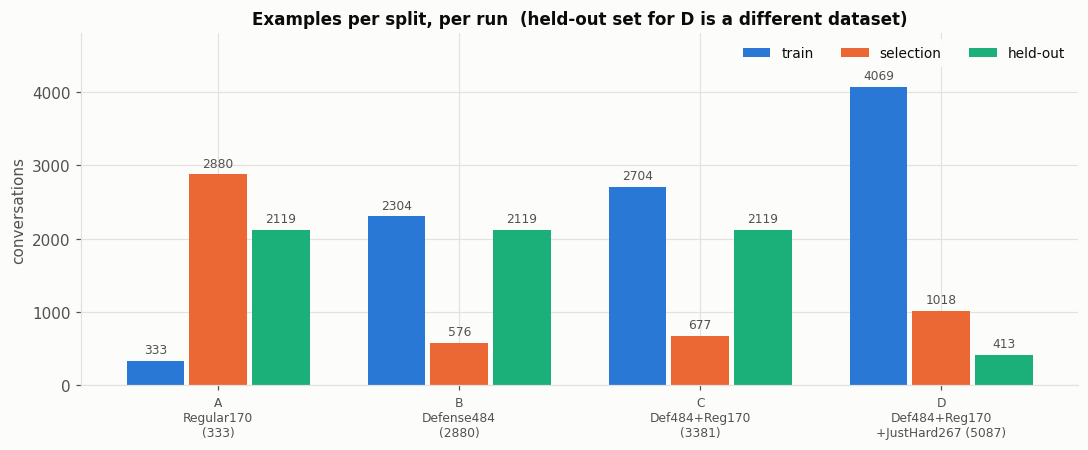

In [7]:
pool = pd.DataFrame([{
    "run": s["id"], "label": s["id"],
    "pool": DATA[(s["id"], "reading")]["metrics"]["n_examples"],
    "train": DATA[(s["id"], "reading")]["metrics"]["n_train"],
    "selection": DATA[(s["id"], "reading")]["metrics"]["n_test"],
    "held-out": DATA[(s["id"], "reading")]["eval"]["n_test"],
} for s in RUN_SPECS])

fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(pool))
w = 0.26
for k, (col, c) in enumerate([("train", CAT[0]), ("selection", CAT[1]), ("held-out", CAT[2])]):
    b = ax.bar(x + (k - 1) * w, pool[col], w * 0.92, color=c, label=col)
    bar_labels(ax, b, "{:.0f}", fontsize=8)
ax.set_xticks(x, [TICK[r] for r in pool["run"]], fontsize=8)
ax.set_ylabel("conversations")
ax.set_title("Examples per split, per run  (held-out set for D is a different dataset)")
ax.set_ylim(0, max(pool[["train", "selection", "held-out"]].values.max() * 1.18, 1))
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

---
# 3. Headline scoreboard

Two numbers per (run, probe): the **selection accuracy** (best layer, best
epoch, on the split used to pick that layer — optimistic) and the **held-out
accuracy** (that same chosen probe applied once to a dataset it never saw —
honest). The gap between them is what generalization costs.

**D's held-out bar is measured on `datasets_ardulous_66`, not
`datasets_hard_333`** — it is hatched throughout the notebook as a reminder
that it cannot be ranked directly against A, B and C. And the left bar is not
the same task across runs: for C and D it is a 3-way accuracy including
`medium`, which is one more reason to treat the selection column as diagnostic
rather than as a score.

run,probe,label,selection acc,held-out acc,held-out macro-F1,held-out loss,best layer,held-out set,n_heldout,generalization gap
A,reading,A·read,0.9368,0.8344,0.8337,0.4633,31,hard_333,2119,0.1024
A,control,A·cont,0.8375,0.6479,0.6418,0.6745,18,hard_333,2119,0.1896
B,reading,B·read,0.9983,0.9382,0.9381,0.2116,25,hard_333,2119,0.0601
B,control,B·cont,0.9965,0.9273,0.9271,0.3133,10,hard_333,2119,0.0692
C,reading,C·read,0.9616,0.9146,0.9139,0.1927,36,hard_333,2119,0.0470
C,control,C·cont,0.9631,0.9004,0.8996,0.2109,31,hard_333,2119,0.0626
D,reading,D·read,0.9509,0.9419,0.9418,0.1496,36,ardulous_66,413,0.0090
D,control,D·cont,0.9587,0.9516,0.9516,0.1421,36,ardulous_66,413,0.0072


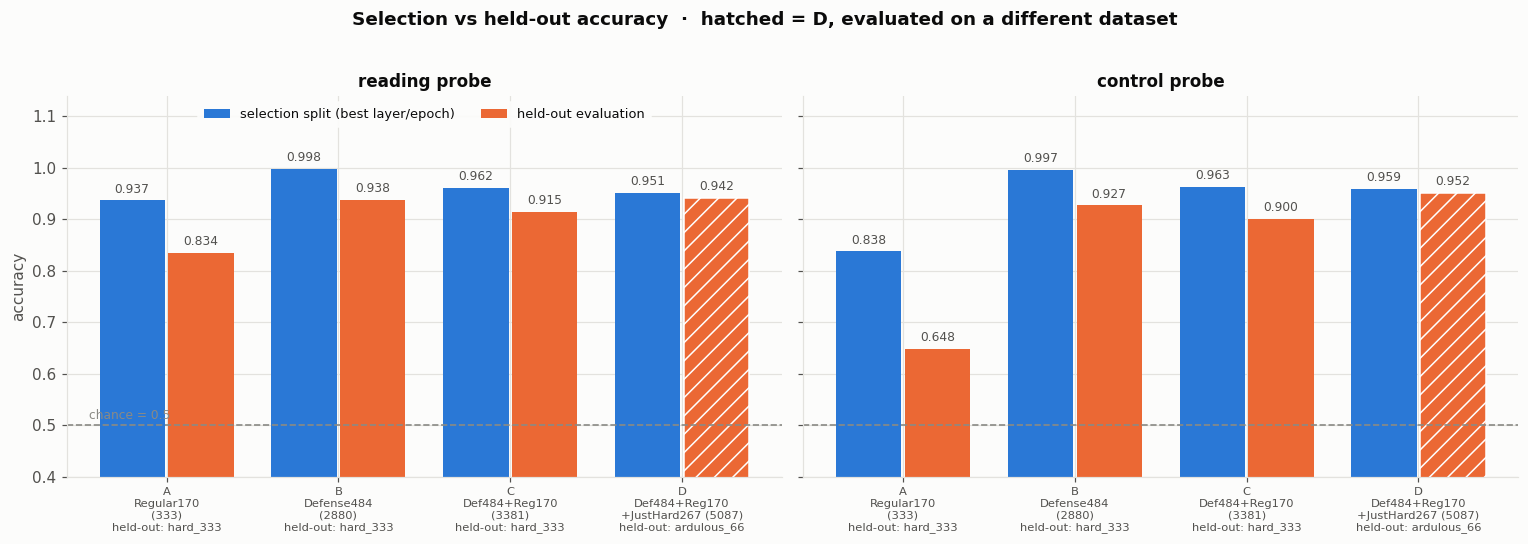

In [8]:
board = pd.DataFrame([{
    "run": rid, "probe": pt,
    "label": f"{rid}·{pt[:4]}",
    "selection acc": DATA[(rid, pt)]["metrics"]["best_acc"],
    "held-out acc": DATA[(rid, pt)]["eval"]["accuracy"],
    "held-out macro-F1": DATA[(rid, pt)]["eval"]["macro_f1"],
    "held-out loss": DATA[(rid, pt)]["eval"]["loss"],
    "best layer": DATA[(rid, pt)]["metrics"]["best_layer"],
    "held-out set": DATA[(rid, pt)]["eval_meta"]["test_dirs"][0].replace("datasets_", ""),
    "n_heldout": DATA[(rid, pt)]["eval"]["n_test"],
} for rid in RUN_IDS for pt in PROBE_TYPES])
board["generalization gap"] = board["selection acc"] - board["held-out acc"]
display(board.style.format({c: "{:.4f}" for c in
        ["selection acc", "held-out acc", "held-out macro-F1", "held-out loss",
         "generalization gap"]}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, pt in zip(axes, PROBE_TYPES):
    sub = board[board["probe"] == pt].set_index("run").loc[RUN_IDS]
    x = np.arange(len(sub))
    b1 = ax.bar(x - 0.2, sub["selection acc"], 0.38, color=CAT[0], label="selection split (best layer/epoch)")
    b2 = ax.bar(x + 0.2, sub["held-out acc"], 0.38, color=CAT[1], label="held-out evaluation")
    for bar, rid in zip(b2, sub.index):
        if rid == "D":
            bar.set_hatch("//")
            bar.set_edgecolor("white")
    bar_labels(ax, b1, "{:.3f}")
    bar_labels(ax, b2, "{:.3f}")
    ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.1)
    ax.set_xticks(x, [f"{TICK[rid]}\nheld-out: {s}" for rid, s in zip(sub.index, sub['held-out set'])],
                  fontsize=7.5)
    ax.set_title(f"{pt} probe")
    ax.set_ylim(0.4, 1.14)
axes[0].set_ylabel("accuracy")
axes[0].annotate("chance = 0.5", (-0.45, 0.512), fontsize=8, color=INK_MUTED)
axes[0].legend(fontsize=8.5, loc="upper center", ncol=2)
fig.suptitle("Selection vs held-out accuracy  ·  hatched = D, evaluated on a different dataset",
             fontsize=12, fontweight="semibold", y=1.02)
plt.tight_layout()
plt.show()

### Reading probe vs control probe, head to head

Same held-out numbers, regrouped so the two probe variants sit side by side per
run. The reading probe appends `" I think the gullibility of this user is"`
before reading the residual stream; the control probe reads the raw
pre-generation boundary — the representation steering actually manipulates.

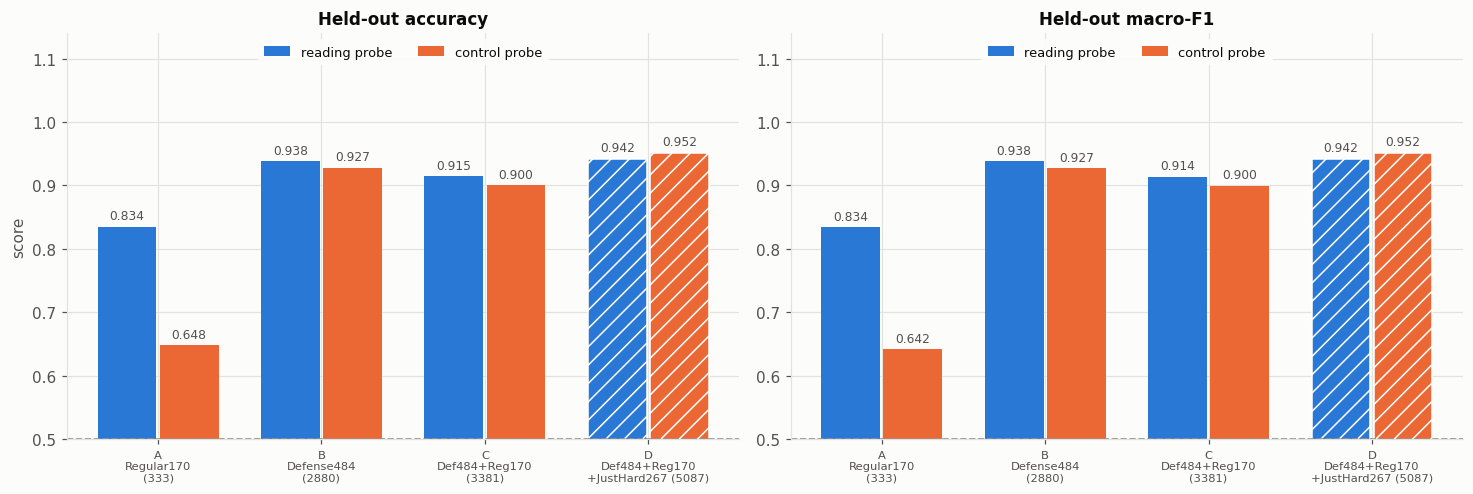

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for ax, metric in zip(axes, ["held-out acc", "held-out macro-F1"]):
    x = np.arange(len(RUN_IDS))
    for k, pt in enumerate(PROBE_TYPES):
        vals = [board[(board.run == r) & (board.probe == pt)][metric].iloc[0] for r in RUN_IDS]
        b = ax.bar(x + (k - 0.5) * 0.38, vals, 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
        for bar, rid in zip(b, RUN_IDS):
            if rid == "D":
                bar.set_hatch("//"); bar.set_edgecolor("white")
        bar_labels(ax, b, "{:.3f}")
    ax.set_xticks(x, [TICK[r] for r in RUN_IDS], fontsize=7.5)
    ax.set_ylim(0.5, 1.14)
    ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.1)
    ax.set_title({"held-out acc": "Held-out accuracy",
                  "held-out macro-F1": "Held-out macro-F1"}[metric])
    ax.legend(fontsize=8.5, loc="upper center", ncol=2)
axes[0].set_ylabel("score")
plt.tight_layout()
plt.show()

### Generalization gap

`selection accuracy − held-out accuracy`. A large positive gap means the
selection split flattered the probe. Run A is the informative outlier: its gap
is enormous for the control probe, i.e. a probe selected on `defense_484` after
training on only 333 `regular_170` conversations does not survive contact with
`hard_333`.

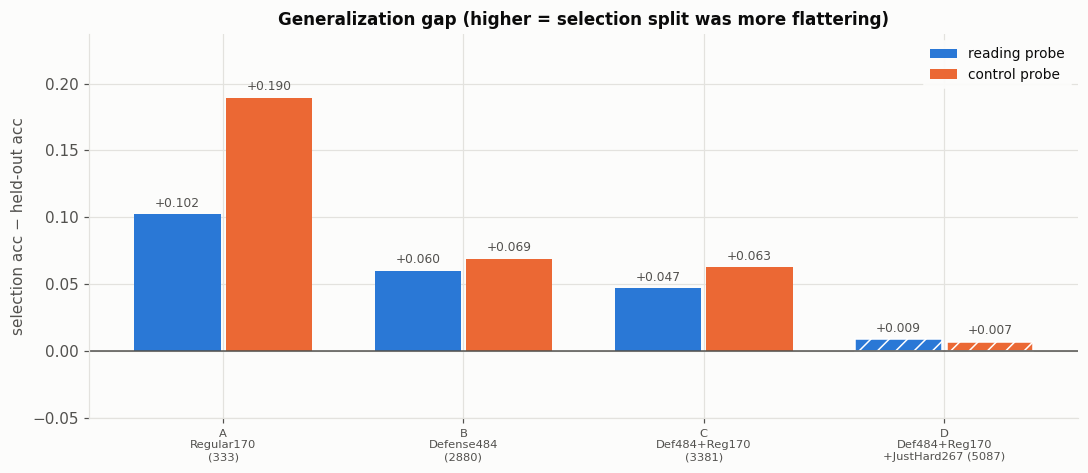

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    vals = [board[(board.run == r) & (board.probe == pt)]["generalization gap"].iloc[0] for r in RUN_IDS]
    b = ax.bar(x + (k - 0.5) * 0.38, vals, 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    for bar, rid in zip(b, RUN_IDS):
        if rid == "D":
            bar.set_hatch("//"); bar.set_edgecolor("white")
    bar_labels(ax, b, "{:+.3f}")
ax.axhline(0, color=INK_SECOND, linewidth=1.0)
ax.set_xticks(x, [TICK[r] for r in RUN_IDS], fontsize=7.5)
ax.set_ylabel("selection acc − held-out acc")
ax.set_title("Generalization gap (higher = selection split was more flattering)")
ax.legend(fontsize=9)
ax.set_ylim(min(-0.05, board["generalization gap"].min() * 1.25), board["generalization gap"].max() * 1.25)
plt.tight_layout()
plt.show()

---
# 4. Accuracy vs. layer depth

The probe is trained independently at each of Llama-2-13B's 41 residual-stream
read points (embedding output + 40 blocks). These curves are the classic
"where does the model represent this attribute" picture: train accuracy at the
final epoch, and selection accuracy at that layer's best epoch.

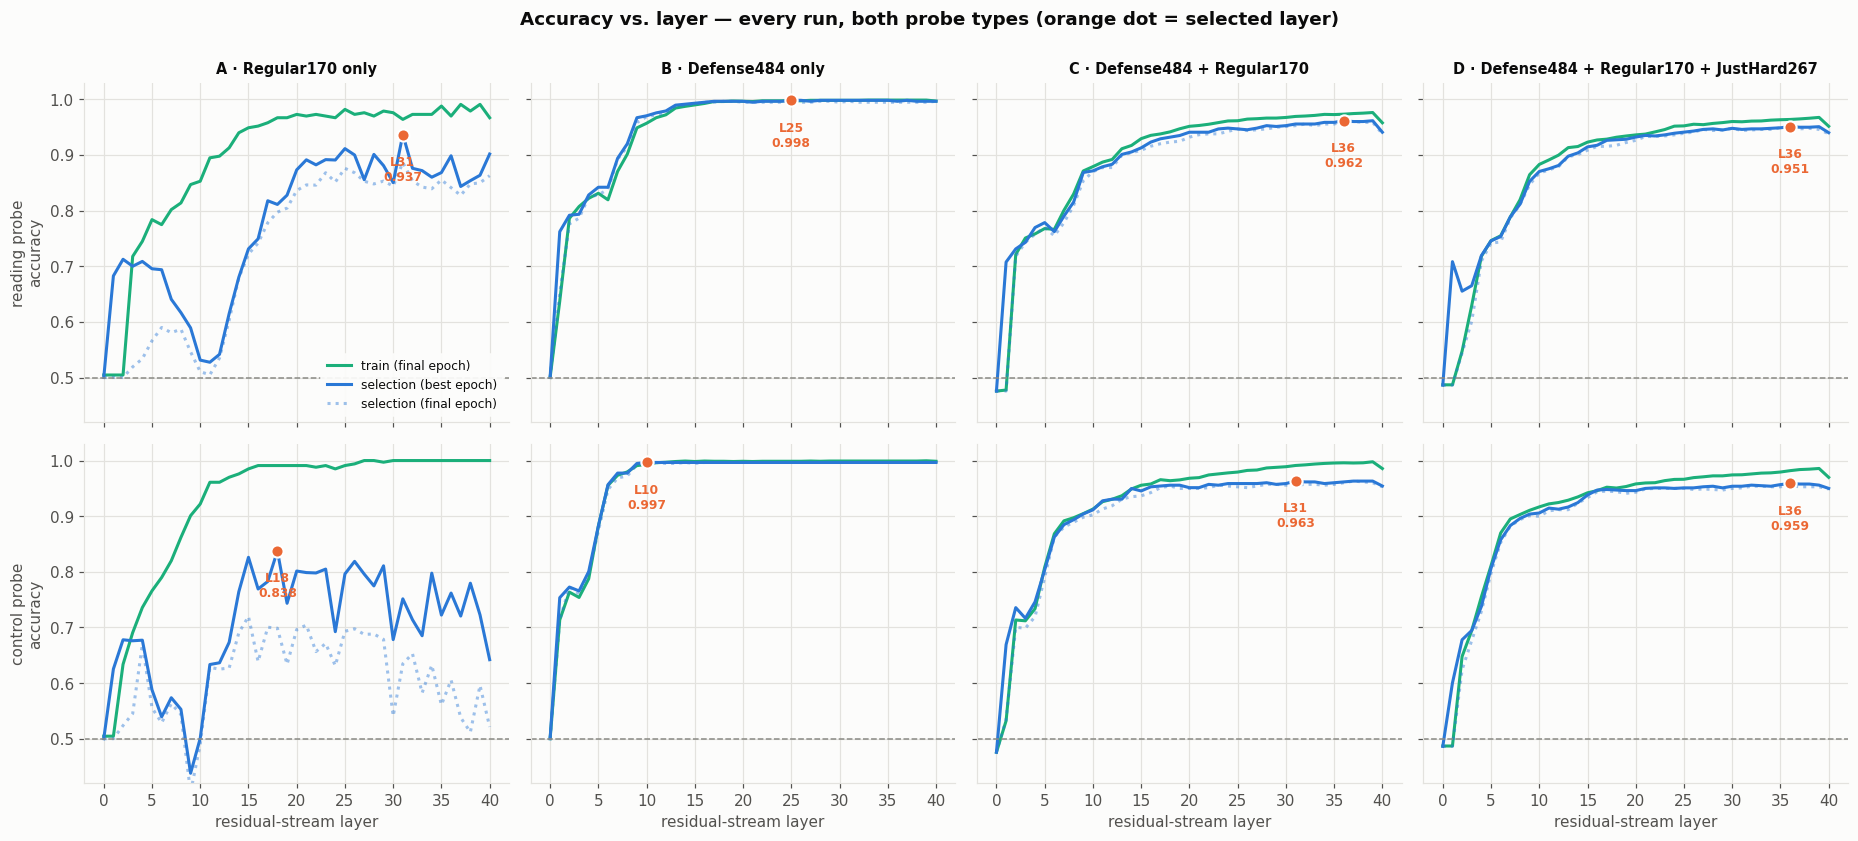

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.6), sharex=True, sharey=True)
for j, spec in enumerate(RUN_SPECS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        m = DATA[(spec["id"], pt)]["metrics"]
        ax.plot(m["layers"], m["train_acc_final_epoch_per_layer"], color=CAT[2],
                label="train (final epoch)")
        ax.plot(m["layers"], m["test_acc_best_epoch_per_layer"], color=CAT[0],
                label="selection (best epoch)")
        ax.plot(m["layers"], m["test_acc_final_epoch_per_layer"], color=CAT[0], alpha=0.45,
                linestyle=":", label="selection (final epoch)")
        bl, ba = m["best_layer"], m["best_acc"]
        ax.scatter([bl], [ba], s=64, zorder=5, color=CAT[1], edgecolor="white", linewidth=1.4)
        ax.annotate(f"L{bl}\n{ba:.3f}", (bl, ba), textcoords="offset points", xytext=(0, -30),
                    ha="center", fontsize=8, color=CAT[1], fontweight="semibold")
        ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.0)
        ax.set_ylim(0.42, 1.03)
        if i == 0:
            ax.set_title(f"{spec['id']} · {spec['short']}", fontsize=9.5)
        if j == 0:
            ax.set_ylabel(f"{pt} probe\naccuracy")
        if i == 1:
            ax.set_xlabel("residual-stream layer")
axes[0, 0].legend(fontsize=8, loc="lower right")
fig.suptitle("Accuracy vs. layer — every run, both probe types (orange dot = selected layer)",
             fontsize=12, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

### All runs overlaid

The same selection-accuracy curves on shared axes, one panel per probe type.
What to look for: how early the curve leaves chance (how shallow a layer
already separates the classes), how flat the plateau is (how robust the layer
choice is), and whether the extra training data lifts the whole curve or just
its peak.

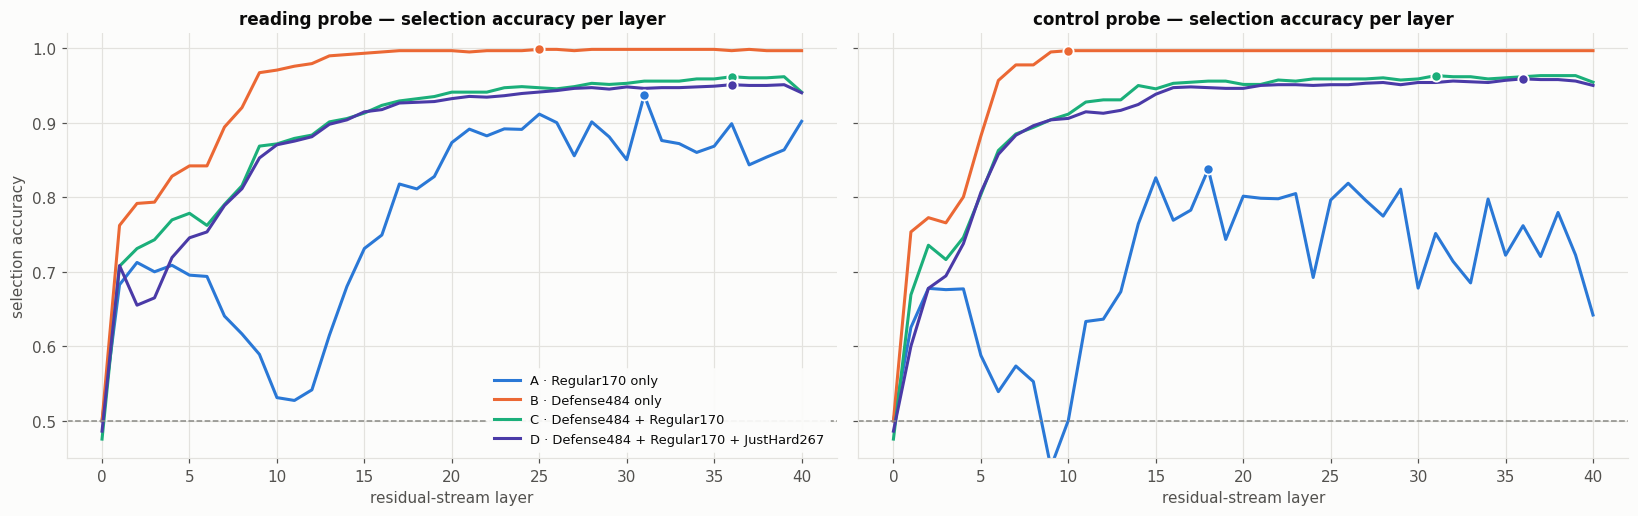

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, pt in zip(axes, PROBE_TYPES):
    for spec in RUN_SPECS:
        m = DATA[(spec["id"], pt)]["metrics"]
        ax.plot(m["layers"], m["test_acc_best_epoch_per_layer"], color=RUN_COLOR[spec["id"]],
                label=f"{spec['id']} · {spec['short']}")
        ax.scatter([m["best_layer"]], [m["best_acc"]], s=45, color=RUN_COLOR[spec["id"]],
                   edgecolor="white", linewidth=1.2, zorder=5)
    ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.0)
    ax.set_title(f"{pt} probe — selection accuracy per layer")
    ax.set_xlabel("residual-stream layer")
    ax.set_ylim(0.45, 1.02)
axes[0].set_ylabel("selection accuracy")
axes[0].legend(fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.show()

### Layer × run accuracy heatmap

The same data as a grid, which makes the *shape* of the depth profile easier to
compare across runs than eight overlaid lines. ★ marks each run's selected
layer.

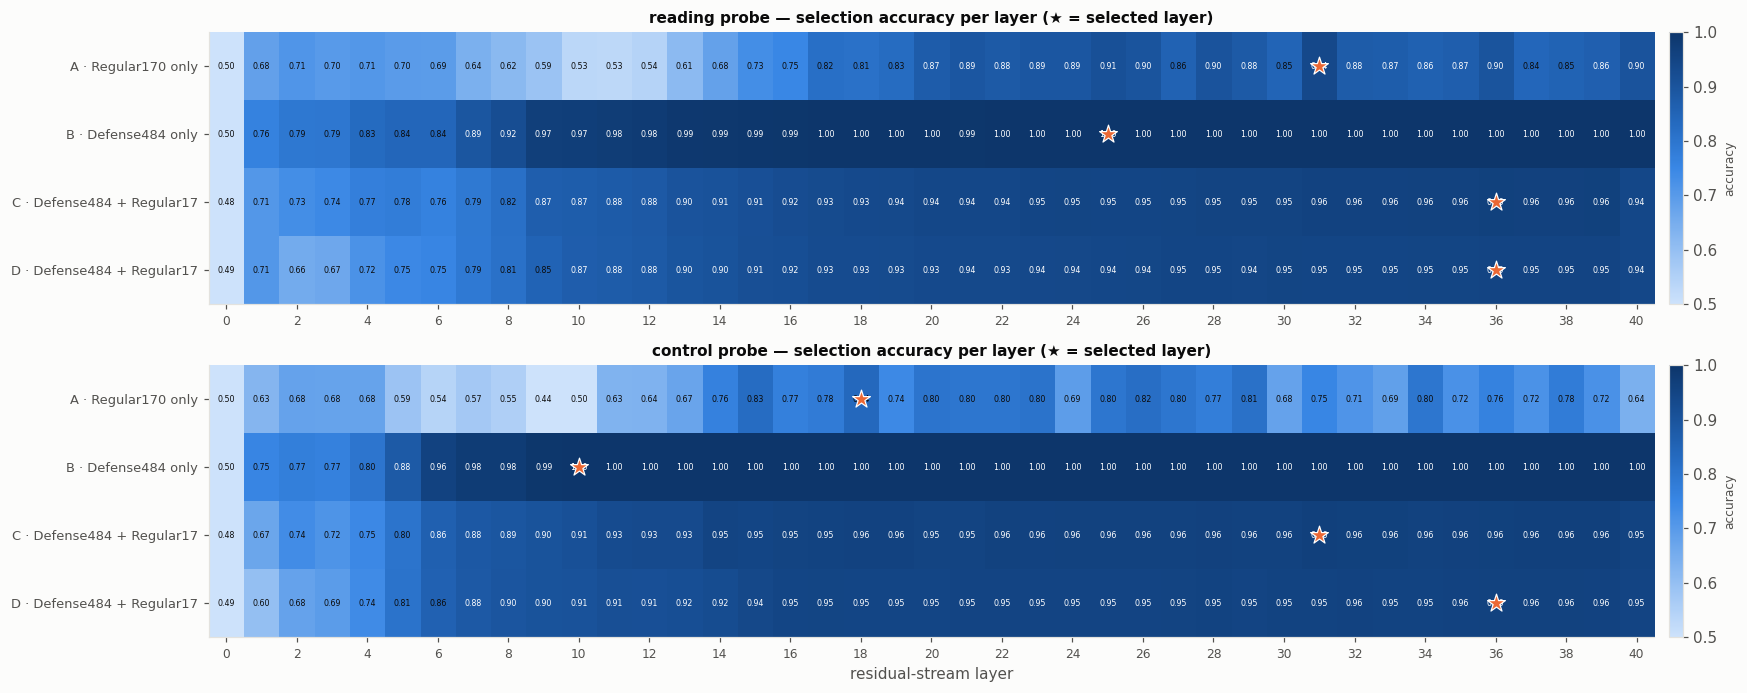

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6.4))
for ax, pt in zip(axes, PROBE_TYPES):
    M = np.array([DATA[(r, pt)]["metrics"]["test_acc_best_epoch_per_layer"] for r in RUN_IDS])
    im = ax.imshow(M, cmap=SEQ_BLUE, vmin=0.5, vmax=1.0, aspect="auto")
    ax.set_yticks(range(len(RUN_IDS)), [f"{r} · {s['short'][:22]}" for r, s in zip(RUN_IDS, RUN_SPECS)],
                  fontsize=8.5)
    ax.set_xticks(range(0, 41, 2), [str(l) for l in range(0, 41, 2)], fontsize=8)
    ax.set_xlabel("residual-stream layer" if pt == "control" else "")
    ax.set_title(f"{pt} probe — selection accuracy per layer (★ = selected layer)", fontsize=10)
    ax.grid(False)
    annotate_grid(ax, M, "{:.2f}", thresh=0.72, fontsize=5.2, vmin=0.5, vmax=1.0)
    for i, r in enumerate(RUN_IDS):
        ax.scatter([DATA[(r, pt)]["metrics"]["best_layer"]], [i], marker="*", s=150,
                   color=CAT[1], edgecolor="white", linewidth=0.8, zorder=5)
    plt.colorbar(im, ax=ax, pad=0.01, fraction=0.02).set_label("accuracy", fontsize=8)
plt.tight_layout()
plt.show()

### Where the selected layer sits, and how much the choice matters

Left: the selected layer index per run. Right: how much accuracy is lost by
taking the *worst* layer in the top-10 band instead of the best — a small
spread means the layer choice is not load-bearing.

run,probe,best layer,depth %,best acc,top-10 mean,top-10 spread,top-5 layers,layers ≥ 0.90
A,reading,31,78%,0.9368,0.9006,0.0545,"L31, L25, L40, L28, L26",5
A,control,18,45%,0.8375,0.8090,0.0413,"L18, L15, L26, L29, L23",0
B,reading,25,62%,0.9983,0.9983,0.0000,"L30, L37, L35, L34, L33",33
B,control,10,25%,0.9965,0.9965,0.0000,"L20, L22, L23, L24, L25",35
C,reading,36,90%,0.9616,0.9581,0.0089,"L39, L36, L38, L37, L35",28
C,control,31,78%,0.9631,0.9616,0.0044,"L38, L37, L31, L39, L36",32
D,reading,36,90%,0.9509,0.9487,0.0039,"L39, L36, L38, L37, L35",27
D,control,36,90%,0.9587,0.9559,0.0049,"L36, L38, L37, L35, L32",32


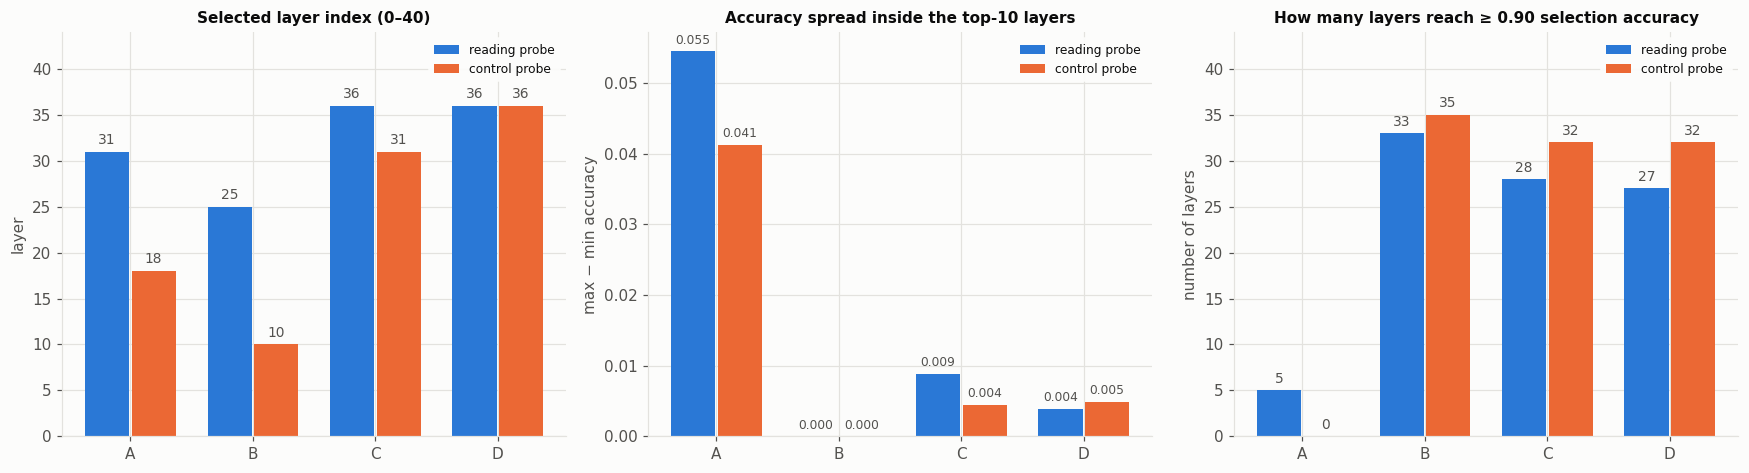

In [14]:
depth_rows = []
for rid in RUN_IDS:
    for pt in PROBE_TYPES:
        m = DATA[(rid, pt)]["metrics"]
        accs = np.array(m["test_acc_best_epoch_per_layer"])
        order = np.argsort(-accs)
        top10 = accs[order[:10]]
        depth_rows.append({
            "run": rid, "probe": pt, "best layer": m["best_layer"],
            "depth %": 100 * m["best_layer"] / 40, "best acc": accs.max(),
            "top-10 mean": top10.mean(), "top-10 spread": top10.max() - top10.min(),
            "top-5 layers": ", ".join(f"L{l}" for l in np.array(m["layers"])[order[:5]]),
            "layers ≥ 0.90": int((accs >= 0.90).sum()),
        })
depth = pd.DataFrame(depth_rows)
display(depth.style.format({"depth %": "{:.0f}%", "best acc": "{:.4f}", "top-10 mean": "{:.4f}",
                            "top-10 spread": "{:.4f}"}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    sub = depth[depth.probe == pt].set_index("run").loc[RUN_IDS]
    b = axes[0].bar(x + (k - 0.5) * 0.38, sub["best layer"], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(axes[0], b, "{:.0f}", fontsize=9)
    b = axes[1].bar(x + (k - 0.5) * 0.38, sub["top-10 spread"], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(axes[1], b, "{:.3f}", fontsize=8)
    b = axes[2].bar(x + (k - 0.5) * 0.38, sub["layers ≥ 0.90"], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(axes[2], b, "{:.0f}", fontsize=9)
for ax, title, ylab in zip(axes,
        ["Selected layer index (0–40)", "Accuracy spread inside the top-10 layers",
         "How many layers reach ≥ 0.90 selection accuracy"],
        ["layer", "max − min accuracy", "number of layers"]):
    ax.set_xticks(x, RUN_IDS)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylab)
    ax.legend(fontsize=8)
axes[0].set_ylim(0, 44)
axes[2].set_ylim(0, 44)
plt.tight_layout()
plt.show()

---
# 5. Training dynamics

Per-epoch curves at each run's selected layer, from the full history pickles.
Loss and accuracy are shown in separate panels — never on twin axes — so the
scales stay honest.

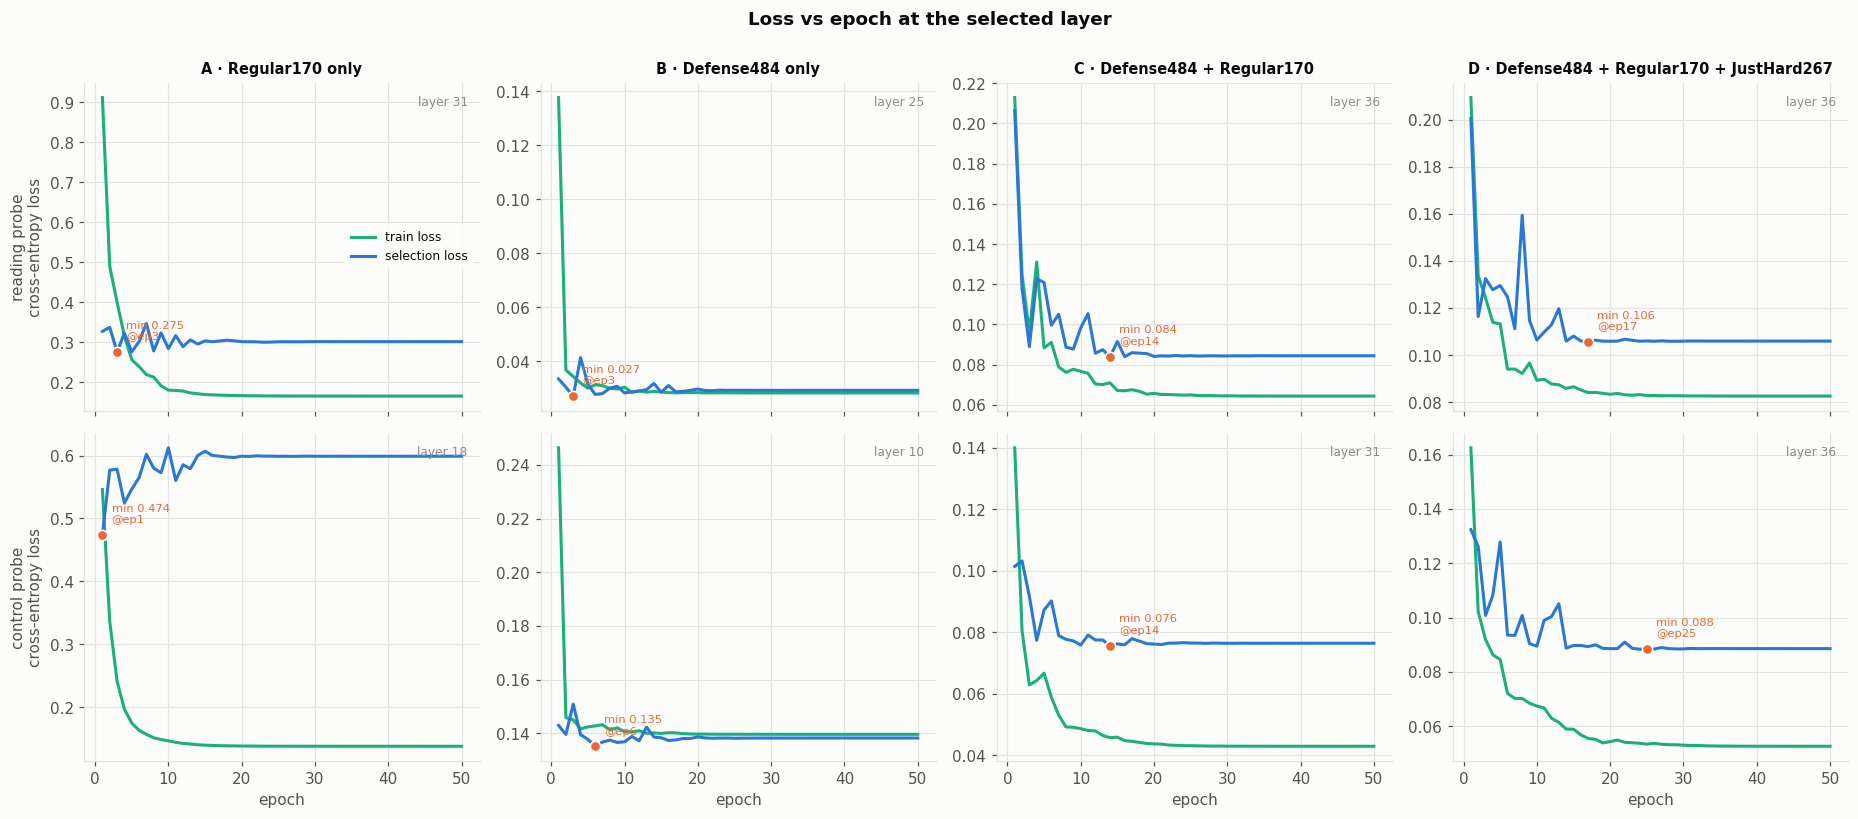

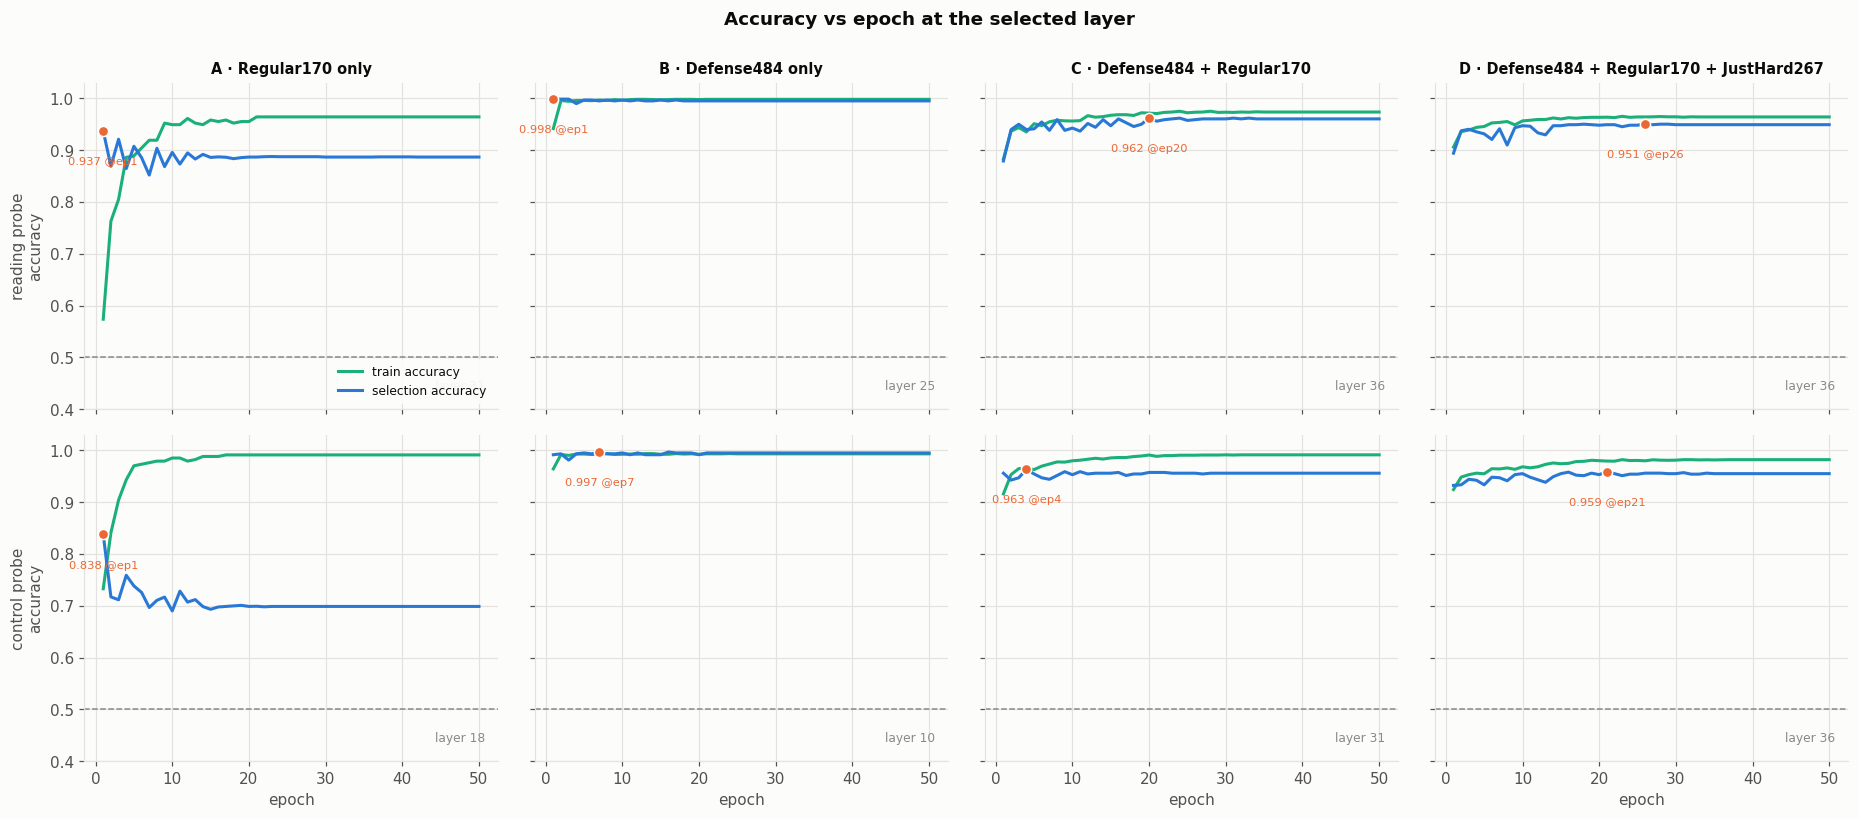

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.4), sharex=True)
for j, spec in enumerate(RUN_SPECS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        rec = DATA[(spec["id"], pt)]
        bl = rec["history"]["best_layer"]
        h = rec["history"]["history_by_layer"][bl]
        ep = np.arange(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], color=CAT[2], label="train loss")
        ax.plot(ep, h["test_loss"], color=CAT[0], label="selection loss")
        k = int(np.argmin(h["test_loss"]))
        ax.scatter([ep[k]], [h["test_loss"][k]], s=45, color=CAT[1], zorder=5, edgecolor="white")
        ax.annotate(f"min {h['test_loss'][k]:.3f}\n@ep{ep[k]}", (ep[k], h["test_loss"][k]),
                    textcoords="offset points", xytext=(6, 8), fontsize=7.5, color=CAT[1])
        if i == 0:
            ax.set_title(f"{spec['id']} · {spec['short']}", fontsize=9.5)
        ax.annotate(f"layer {bl}", (0.97, 0.93), xycoords="axes fraction", ha="right",
                    fontsize=8, color=INK_MUTED)
        if j == 0:
            ax.set_ylabel(f"{pt} probe\ncross-entropy loss")
        if i == 1:
            ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Loss vs epoch at the selected layer", fontsize=12, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(17, 7.4), sharex=True, sharey=True)
for j, spec in enumerate(RUN_SPECS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        rec = DATA[(spec["id"], pt)]
        bl = rec["history"]["best_layer"]
        h = rec["history"]["history_by_layer"][bl]
        ep = np.arange(1, len(h["train_acc"]) + 1)
        ax.plot(ep, h["train_acc"], color=CAT[2], label="train accuracy")
        ax.plot(ep, h["test_acc"], color=CAT[0], label="selection accuracy")
        k = int(np.argmax(h["test_acc"]))
        ax.scatter([ep[k]], [h["test_acc"][k]], s=45, color=CAT[1], zorder=5, edgecolor="white")
        ax.annotate(f"{h['test_acc'][k]:.3f} @ep{ep[k]}", (ep[k], h["test_acc"][k]),
                    textcoords="offset points", xytext=(0, -22), ha="center", fontsize=7.5, color=CAT[1])
        ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.0)
        ax.set_ylim(0.4, 1.03)
        if i == 0:
            ax.set_title(f"{spec['id']} · {spec['short']}", fontsize=9.5)
        ax.annotate(f"layer {bl}", (0.97, 0.06), xycoords="axes fraction", ha="right",
                    fontsize=8, color=INK_MUTED)
        if j == 0:
            ax.set_ylabel(f"{pt} probe\naccuracy")
        if i == 1:
            ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=8, loc="lower right")
fig.suptitle("Accuracy vs epoch at the selected layer", fontsize=12, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

### Convergence speed and overfitting

* **Epochs to 99% of final train accuracy** — how fast the linear probe fits.
* **Train − selection accuracy at the final epoch** — the memorization gap; run
  A's tiny 333-example training set fits perfectly within a few epochs, which is
  exactly where its transfer problems come from.

run,probe,layer,epochs to 99% of final train acc,final train acc,final selection acc,best selection acc,train−selection gap (final),selection acc drift (best→final),final train loss,final selection loss
A,reading,31,12,0.9640,0.8865,0.9368,0.0775,0.0503,0.1654,0.3016
A,control,18,10,0.9910,0.6986,0.8375,0.2924,0.1389,0.1378,0.5990
B,reading,25,2,0.9978,0.9948,0.9983,0.0030,0.0035,0.0284,0.0293
B,control,10,2,0.9931,0.9948,0.9965,-0.0017,0.0017,0.1396,0.1382
C,reading,36,12,0.9734,0.9601,0.9616,0.0133,0.0015,0.0644,0.0844
C,control,31,12,0.9911,0.9557,0.9631,0.0354,0.0074,0.0429,0.0765
D,reading,36,8,0.9639,0.9489,0.9509,0.0150,0.0020,0.0826,0.1059
D,control,36,13,0.9818,0.9548,0.9587,0.0270,0.0039,0.0526,0.0885


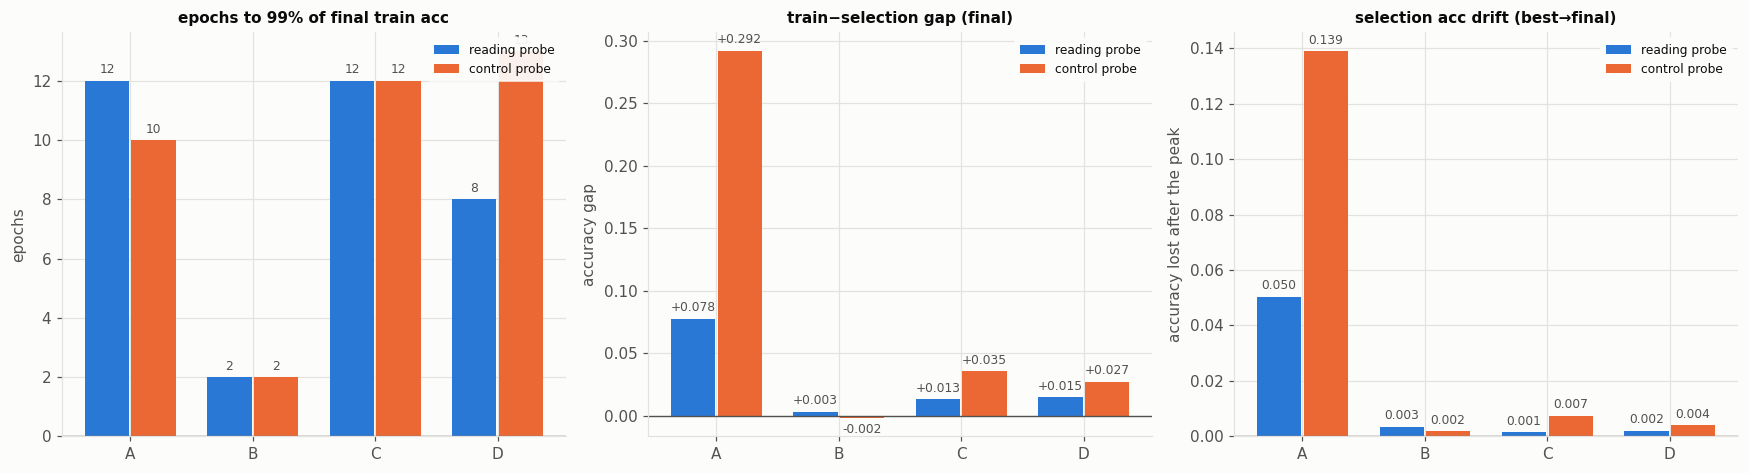

In [16]:
conv_rows = []
for rid in RUN_IDS:
    for pt in PROBE_TYPES:
        rec = DATA[(rid, pt)]
        bl = rec["history"]["best_layer"]
        h = rec["history"]["history_by_layer"][bl]
        tr, te = np.array(h["train_acc"]), np.array(h["test_acc"])
        target = 0.99 * tr[-1]
        reach = int(np.argmax(tr >= target)) + 1
        conv_rows.append({
            "run": rid, "probe": pt, "layer": bl,
            "epochs to 99% of final train acc": reach,
            "final train acc": tr[-1], "final selection acc": te[-1],
            "best selection acc": te.max(),
            "train−selection gap (final)": tr[-1] - te[-1],
            "selection acc drift (best→final)": te.max() - te[-1],
            "final train loss": h["train_loss"][-1], "final selection loss": h["test_loss"][-1],
        })
conv = pd.DataFrame(conv_rows)
display(conv.style.format({c: "{:.4f}" for c in conv.columns if conv[c].dtype == float}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
x = np.arange(len(RUN_IDS))
panels = [("epochs to 99% of final train acc", "epochs", "{:.0f}"),
          ("train−selection gap (final)", "accuracy gap", "{:+.3f}"),
          ("selection acc drift (best→final)", "accuracy lost after the peak", "{:.3f}")]
for ax, (col, ylab, fmt) in zip(axes, panels):
    for k, pt in enumerate(PROBE_TYPES):
        sub = conv[conv.probe == pt].set_index("run").loc[RUN_IDS]
        b = ax.bar(x + (k - 0.5) * 0.38, sub[col], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
        bar_labels(ax, b, fmt, fontsize=8)
    ax.set_xticks(x, RUN_IDS)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(ylab)
    ax.axhline(0, color=INK_SECOND, linewidth=0.9)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Overfitting across the whole depth profile

Not just at the selected layer: `train − selection` accuracy at the final epoch
for every layer. A curve that climbs with depth means the deeper features are
rich enough for the probe to memorize the training split.

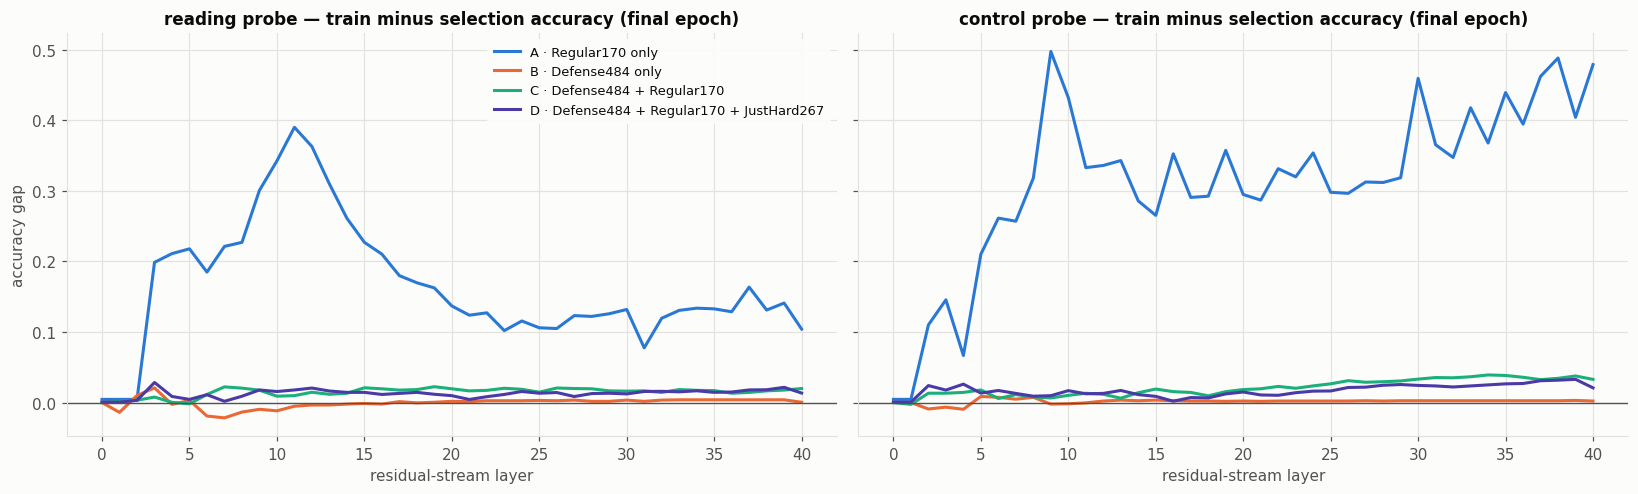

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for ax, pt in zip(axes, PROBE_TYPES):
    for spec in RUN_SPECS:
        m = DATA[(spec["id"], pt)]["metrics"]
        gap = np.array(m["train_acc_final_epoch_per_layer"]) - np.array(m["test_acc_final_epoch_per_layer"])
        ax.plot(m["layers"], gap, color=RUN_COLOR[spec["id"]], label=f"{spec['id']} · {spec['short']}")
    ax.axhline(0, color=INK_SECOND, linewidth=0.9)
    ax.set_xlabel("residual-stream layer")
    ax.set_title(f"{pt} probe — train minus selection accuracy (final epoch)")
axes[0].set_ylabel("accuracy gap")
axes[0].legend(fontsize=8.5)
plt.tight_layout()
plt.show()

---
# 6. Held-out evaluation, in detail

From here on the analysis uses `eval/gullibility_test_scores.csv` — one row per
held-out conversation with its true label, predicted label and the probe's
score. That per-example resolution is what makes ROC, calibration, threshold and
error-overlap analysis possible.

### What the `score` column actually is

The probe head is `nn.Linear(5120, n_classes) → nn.Sigmoid()` trained with
`BCELoss` against a one-hot target (`src/probe_common.py`), **not** a softmax
classifier. So each class has its own independent sigmoid unit, the two units do
not sum to 1, and:

* `score` = **σ(high)**, the high unit alone — written by
  `_write_score_report` as `probs[:, index("high")]`;
* `predicted_label` = **argmax over the units**, i.e. `σ(high) > σ(low)`, which
  (sigmoid being monotone) is exactly the sign of
  `(w_high − w_low)·act + (b_high − b_low)` — the decision direction analysed in
  section 9.

The two rules are not the same rule. Thresholding σ(high) at 0.5 asks
"is the high unit on?", while the shipped prediction asks "is the high unit
larger than the low unit?". The cell below quantifies how often they disagree —
it matters a lot for run A and barely at all for the rest. Everywhere below,
"score" means σ(high) and accuracy always comes from the shipped
`predicted_label`.

run,probe,n,topics,shipped accuracy (argmax),accuracy if σ(high) ≥ 0.5,rows where the two rules disagree,disagreement rate
A,reading,2119,34,0.8344,0.8490,163,0.0769
A,control,2119,34,0.6479,0.6470,100,0.0472
B,reading,2119,34,0.9382,0.9382,2,0.0009
B,control,2119,34,0.9273,0.9273,0,0.0000
C,reading,2119,34,0.9146,0.9179,31,0.0146
C,control,2119,34,0.9004,0.8896,55,0.0260
D,reading,413,22,0.9419,0.9370,4,0.0097
D,control,413,22,0.9516,0.9492,1,0.0024


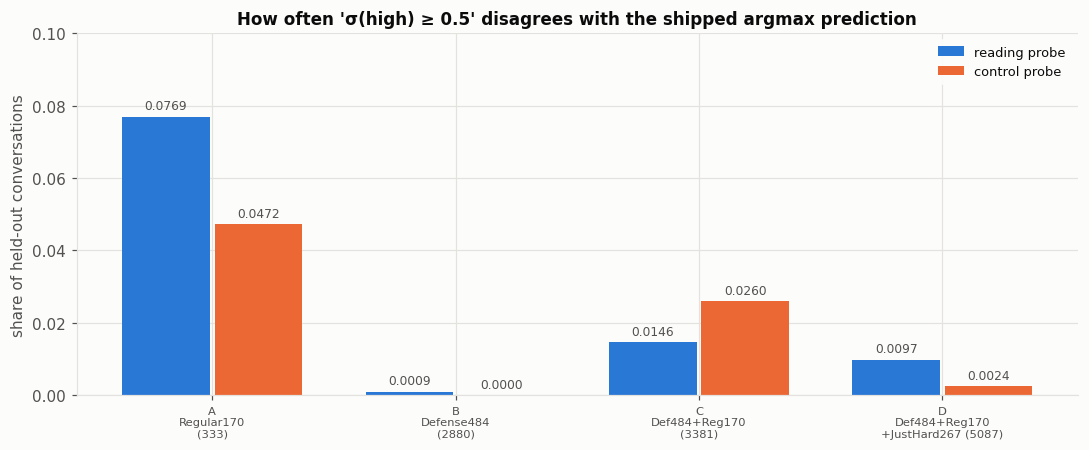

In [18]:
def load_scores(rid, pt):
    rec = DATA[(rid, pt)]
    df = rec["scores"].copy()
    df["y_true"] = (df["true_label"] == "high").astype(int)
    df["y_pred"] = (df["predicted_label"] == "high").astype(int)
    df["correct"] = (df["y_true"] == df["y_pred"]).astype(int)
    df["p_high"] = df["score"].astype(float)
    # how far the high unit sits from its own midpoint, and how hard it pushed
    # toward the wrong class (only meaningful on errors)
    df["unit_margin"] = (df["p_high"] - 0.5).abs()
    df["wrongness"] = np.where(df["y_true"] == 1, 1 - df["p_high"], df["p_high"])
    df["thr_pred"] = (df["p_high"] >= 0.5).astype(int)
    df["rule_disagrees"] = (df["thr_pred"] != df["y_pred"]).astype(int)
    df["basename"] = df["file"].apply(lambda p: os.path.basename(p))
    df["topic"] = df["basename"].str.replace(r"^conversation_\d+_\d+_", "", regex=True) \
                                .str.replace(rf"_{ATTR}_(high|low|medium)\.txt$", "", regex=True)
    df.loc[df["topic"].str.startswith("conversation_"), "topic"] = "untagged"
    df["run"], df["probe"] = rid, pt
    return df

SC = {(rid, pt): load_scores(rid, pt) for rid in RUN_IDS for pt in PROBE_TYPES}
rule = pd.DataFrame([{
    "run": rid, "probe": pt, "n": len(SC[(rid, pt)]),
    "topics": SC[(rid, pt)]["topic"].nunique(),
    "shipped accuracy (argmax)": SC[(rid, pt)]["correct"].mean(),
    "accuracy if σ(high) ≥ 0.5": (SC[(rid, pt)]["thr_pred"] == SC[(rid, pt)]["y_true"]).mean(),
    "rows where the two rules disagree": int(SC[(rid, pt)]["rule_disagrees"].sum()),
    "disagreement rate": SC[(rid, pt)]["rule_disagrees"].mean(),
} for rid in RUN_IDS for pt in PROBE_TYPES])
display(rule.style.format({"shipped accuracy (argmax)": "{:.4f}", "accuracy if σ(high) ≥ 0.5": "{:.4f}",
                           "disagreement rate": "{:.4f}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    sub = rule[rule.probe == pt].set_index("run").loc[RUN_IDS]
    b = ax.bar(x + (k - 0.5) * 0.38, sub["disagreement rate"], 0.36, color=PROBE_COLOR[pt],
               label=f"{pt} probe")
    bar_labels(ax, b, "{:.4f}", fontsize=8)
ax.set_xticks(x, [TICK[r] for r in RUN_IDS], fontsize=7.5)
ax.set_ylabel("share of held-out conversations")
ax.set_title("How often 'σ(high) ≥ 0.5' disagrees with the shipped argmax prediction")
ax.legend(fontsize=8.5)
ax.set_ylim(0, max(rule["disagreement rate"].max() * 1.3, 0.01))
plt.tight_layout()
plt.show()

### Confusion matrices on the held-out set

Counts with the row-normalized rate underneath, so class-conditional error is
readable directly. Rows are the truth, columns the prediction.

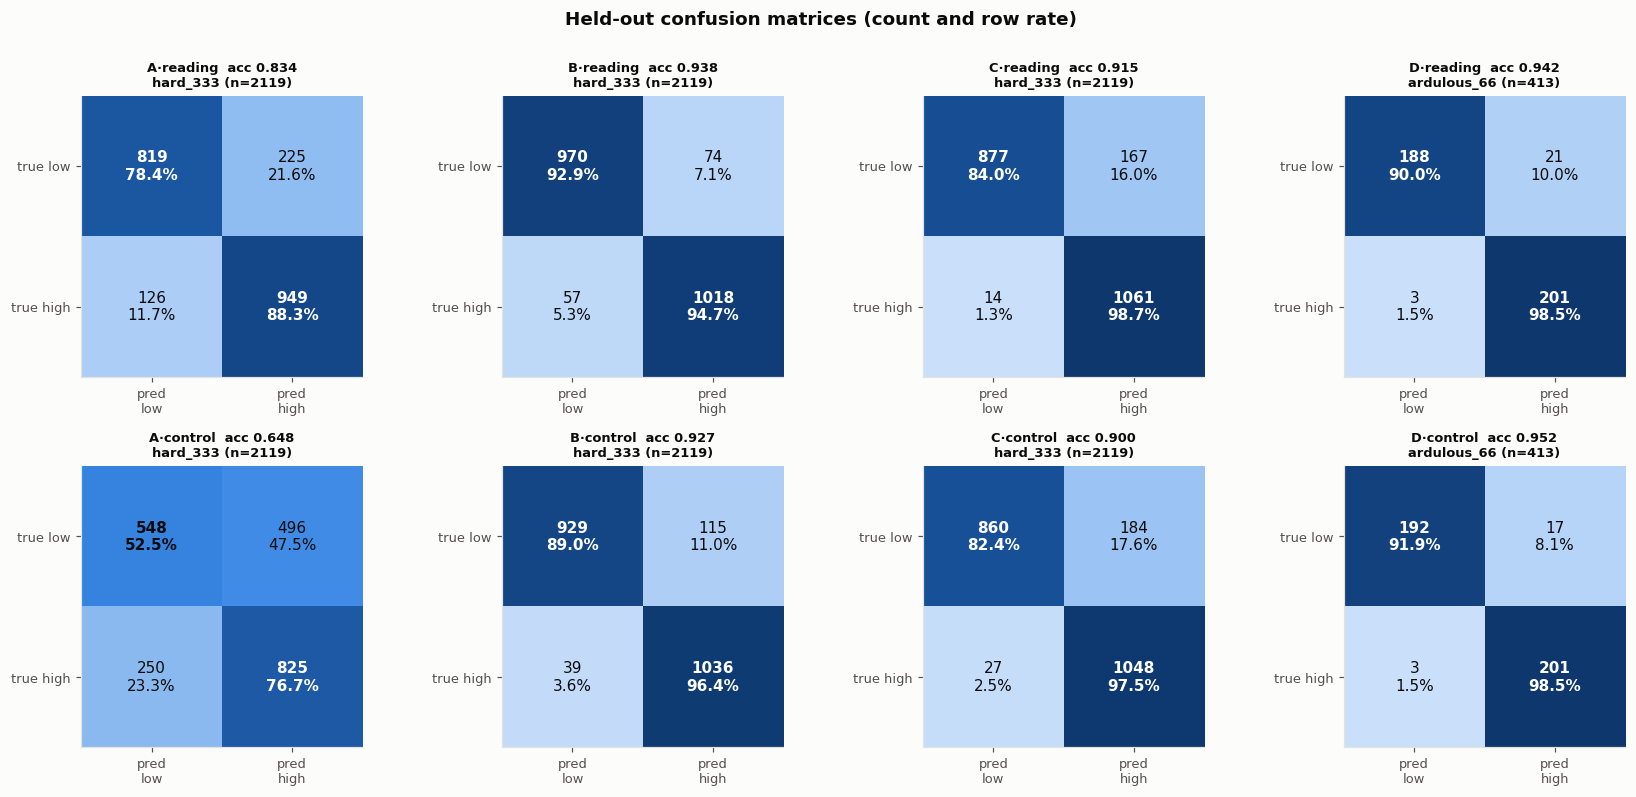

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.2))
for j, spec in enumerate(RUN_SPECS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        ev = DATA[(spec["id"], pt)]["eval"]
        cm = np.array(ev["confusion_matrix"], dtype=float)
        cls = ev["class_names"]
        rown = cm / cm.sum(axis=1, keepdims=True)
        ax.imshow(rown, cmap=SEQ_BLUE, vmin=0, vmax=1)
        for a in range(cm.shape[0]):
            for b in range(cm.shape[1]):
                ax.text(b, a, f"{int(cm[a,b])}\n{100*rown[a,b]:.1f}%", ha="center", va="center",
                        fontsize=10, color="white" if rown[a, b] > 0.55 else INK,
                        fontweight="semibold" if a == b else "normal")
        ax.set_xticks(range(len(cls)), [f"pred\n{c}" for c in cls], fontsize=8.5)
        ax.set_yticks(range(len(cls)), [f"true {c}" for c in cls], fontsize=8.5)
        ax.grid(False)
        ax.set_title(f"{spec['id']}·{pt}  acc {ev['accuracy']:.3f}\n"
                     f"{ev['meta']['test_dirs'][0].replace('datasets_','')} (n={ev['n_test']})",
                     fontsize=8.5)
fig.suptitle("Held-out confusion matrices (count and row rate)", fontsize=12,
             fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

### Per-class precision / recall / F1

Whether a run's errors are symmetric matters for downstream use: a probe used
as a "this user is being credulous" detector cares about `high` recall, while a
steering direction cares mostly about both classes being cleanly separated.

F1         precision          recall        
class          high     low      high     low    high     low
run probe                                                    
A   control  0.6886  0.5950    0.6245  0.6867  0.7674  0.5249
    reading  0.8439  0.8235    0.8083  0.8667  0.8828  0.7845
B   control  0.9308  0.9235    0.9001  0.9597  0.9637  0.8898
    reading  0.9395  0.9367    0.9322  0.9445  0.9470  0.9291
C   control  0.9085  0.8907    0.8506  0.9696  0.9749  0.8238
    reading  0.9214  0.9065    0.8640  0.9843  0.9870  0.8400
D   control  0.9526  0.9505    0.9220  0.9846  0.9853  0.9187
    reading  0.9437  0.9400    0.9054  0.9843  0.9853  0.8995

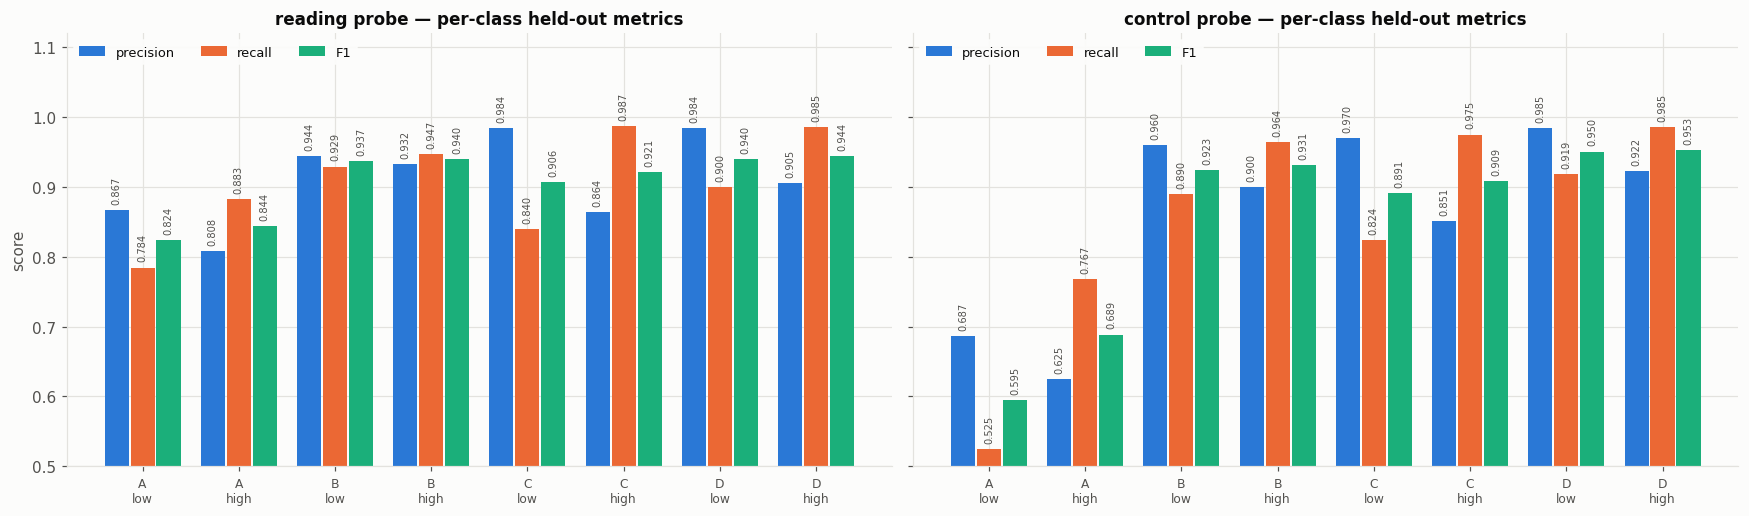

In [20]:
pc_rows = []
for rid in RUN_IDS:
    for pt in PROBE_TYPES:
        ev = DATA[(rid, pt)]["eval"]
        for cls in ev["class_names"]:
            pc_rows.append({"run": rid, "probe": pt, "class": cls,
                            "precision": ev["precision_per_class"][cls],
                            "recall": ev["recall_per_class"][cls],
                            "F1": ev["f1_per_class"][cls],
                            "support": ev["support_per_class"][cls]})
per_class = pd.DataFrame(pc_rows)
display(per_class.pivot_table(index=["run", "probe"], columns="class",
                              values=["precision", "recall", "F1"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
for ax, pt in zip(axes, PROBE_TYPES):
    sub = per_class[per_class.probe == pt]
    labels = [f"{r}\n{c}" for r in RUN_IDS for c in ["low", "high"]]
    x = np.arange(len(labels))
    for k, (metric, c) in enumerate([("precision", CAT[0]), ("recall", CAT[1]), ("F1", CAT[2])]):
        vals = [sub[(sub.run == r) & (sub["class"] == cl)][metric].iloc[0]
                for r in RUN_IDS for cl in ["low", "high"]]
        b = ax.bar(x + (k - 1) * 0.27, vals, 0.25, color=c, label=metric)
        bar_labels(ax, b, "{:.3f}", fontsize=6.5, rotation=90, dy=4)
    ax.set_xticks(x, labels, fontsize=8)
    ax.set_ylim(0.5, 1.12)
    ax.set_title(f"{pt} probe — per-class held-out metrics")
    ax.legend(fontsize=8.5, ncol=3, loc="upper left")
axes[0].set_ylabel("score")
plt.tight_layout()
plt.show()

---
# 7. Score distributions — how separated are the two classes?

Accuracy hides *margin*. These histograms show σ(high) for truly-`low` (blue)
and truly-`high` (orange) conversations. A probe whose mass piles up at 0 and 1
in the right places is separating the classes with room to spare; one with mass
bunched near 0.5 is hedging even where it happens to be right. The dashed line
is 0.5 on the high unit — remember it is *not* the shipped decision boundary
(that one involves the low unit too), so a bar sitting on the wrong side of it
is not automatically an error.

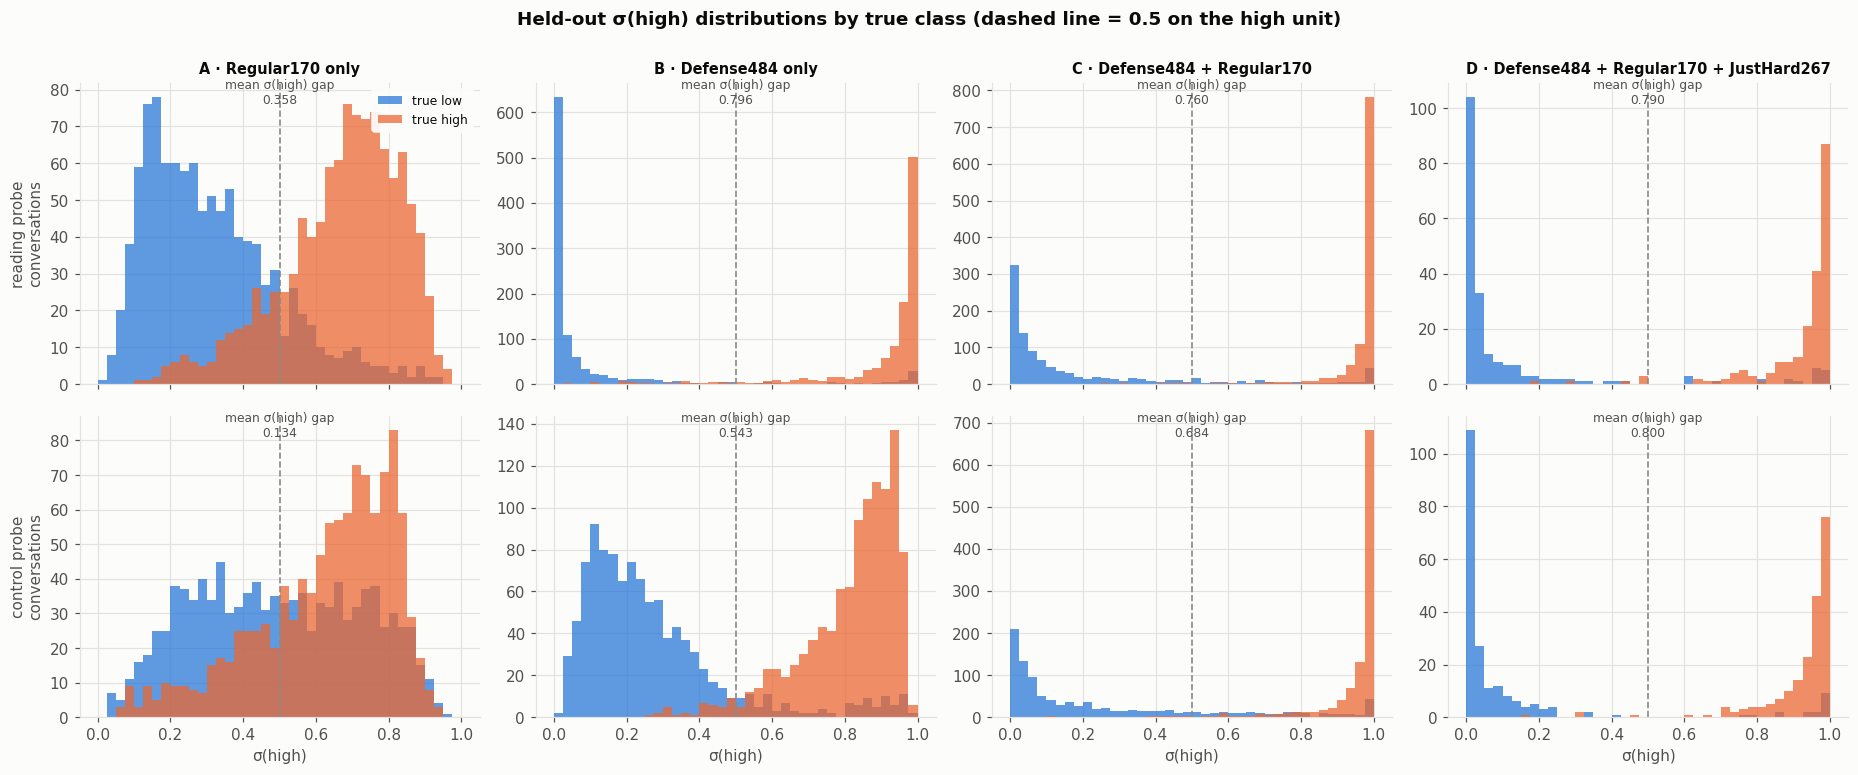

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.0), sharex=True)
bins = np.linspace(0, 1, 41)
for j, spec in enumerate(RUN_SPECS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        df = SC[(spec["id"], pt)]
        ax.hist(df.loc[df.y_true == 0, "p_high"], bins=bins, color=CAT[0], alpha=0.75, label="true low")
        ax.hist(df.loc[df.y_true == 1, "p_high"], bins=bins, color=CAT[1], alpha=0.75, label="true high")
        ax.axvline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.1)
        sep = df.loc[df.y_true == 1, "p_high"].mean() - df.loc[df.y_true == 0, "p_high"].mean()
        ax.annotate(f"mean σ(high) gap\n{sep:.3f}", (0.5, 0.93), xycoords=("data", "axes fraction"),
                    ha="center", fontsize=8, color=INK_SECOND)
        if i == 0:
            ax.set_title(f"{spec['id']} · {spec['short']}", fontsize=9.5)
        if j == 0:
            ax.set_ylabel(f"{pt} probe\nconversations")
        if i == 1:
            ax.set_xlabel("σ(high)")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Held-out σ(high) distributions by true class (dashed line = 0.5 on the high unit)",
             fontsize=12, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

### Threshold-free quality: ROC and precision–recall

AUC and average precision answer "how good is the *ranking*", independently of
where any cut falls — useful because a probe with a bad threshold but good
ranking is fixable by recalibration, while a probe with bad AUC is not. Both are
computed on σ(high), the only per-example score the eval artifacts record; the
shipped rule also consults the low unit, so read these as the quality of the
high unit's ordering rather than of the exact deployed classifier.

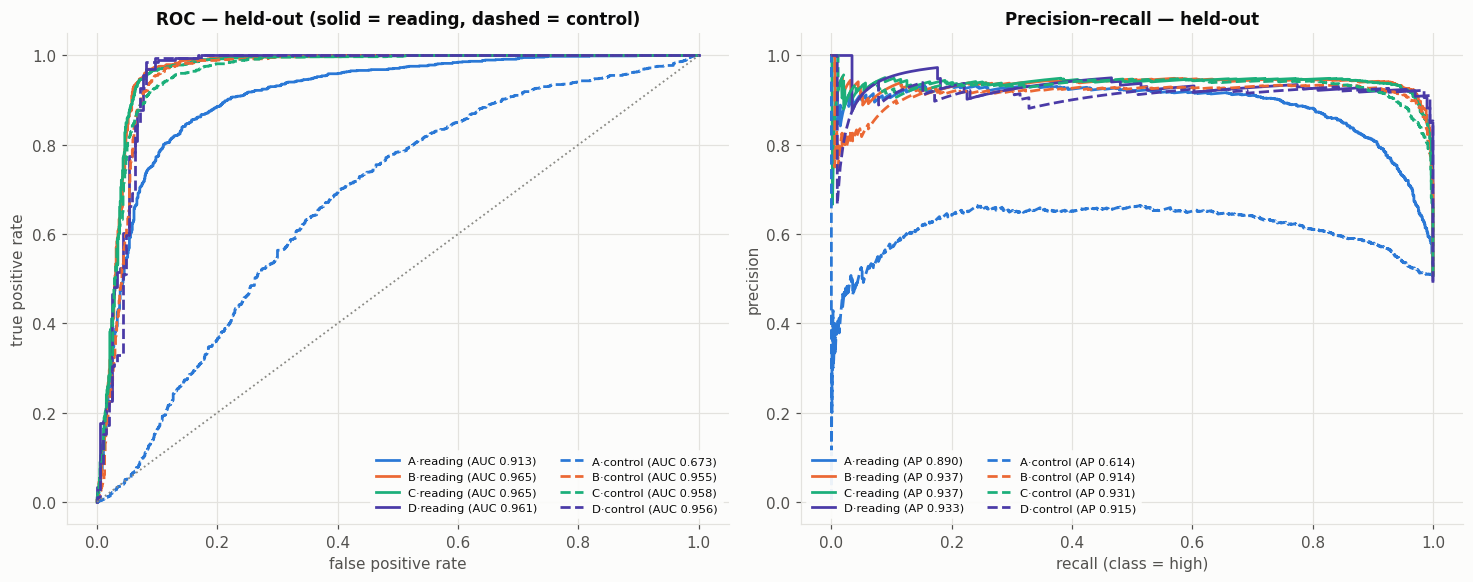

run,probe,AUC,avg precision,accuracy,mean σ(high) gap,brier
A,reading,0.9127,0.8905,0.8344,0.3576,0.1329
B,reading,0.9651,0.9366,0.9382,0.7961,0.0522
C,reading,0.9647,0.9373,0.9146,0.7598,0.0635
D,reading,0.9613,0.9331,0.9419,0.7896,0.0529
A,control,0.6729,0.6143,0.6479,0.1337,0.2336
B,control,0.9549,0.9140,0.9273,0.5425,0.0834
C,control,0.9578,0.9309,0.9004,0.6844,0.0844
D,control,0.9560,0.9148,0.9516,0.8003,0.0490


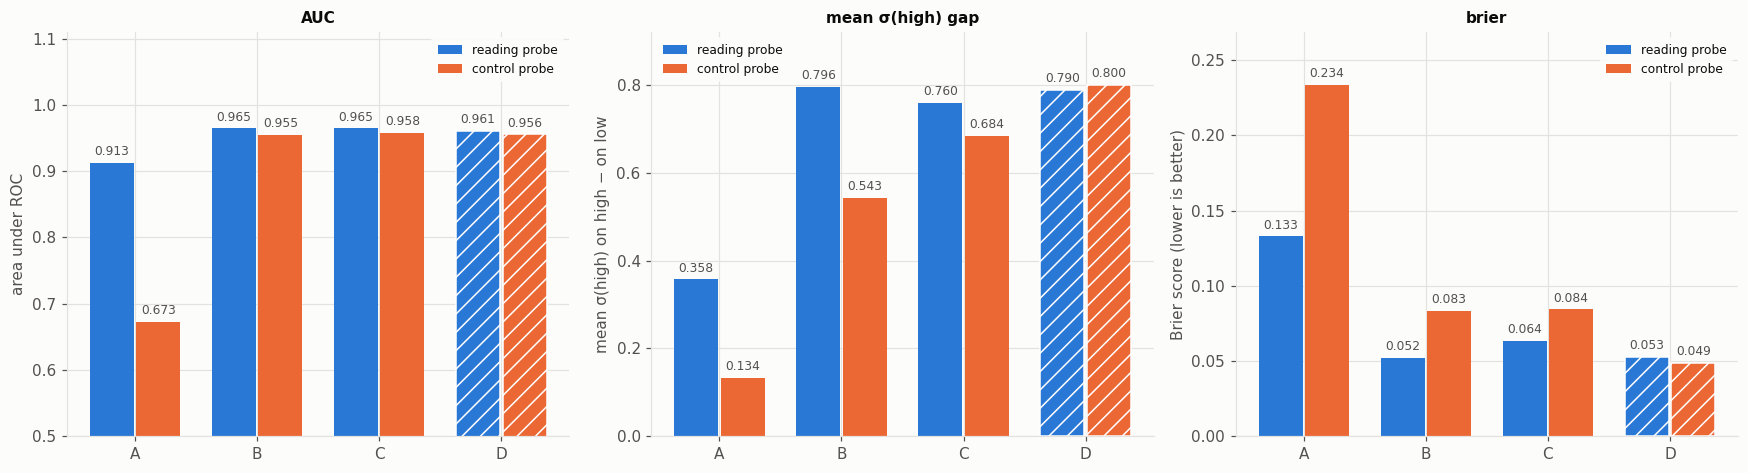

In [22]:
auc_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
for pt, ls in zip(PROBE_TYPES, ["-", "--"]):
    for spec in RUN_SPECS:
        df = SC[(spec["id"], pt)]
        fpr, tpr, _ = roc_curve(df.y_true, df.p_high)
        a = auc(fpr, tpr)
        ap = average_precision_score(df.y_true, df.p_high)
        prec, rec, _ = precision_recall_curve(df.y_true, df.p_high)
        axes[0].plot(fpr, tpr, color=RUN_COLOR[spec["id"]], linestyle=ls, linewidth=1.8,
                     label=f"{spec['id']}·{pt} (AUC {a:.3f})")
        axes[1].plot(rec, prec, color=RUN_COLOR[spec["id"]], linestyle=ls, linewidth=1.8,
                     label=f"{spec['id']}·{pt} (AP {ap:.3f})")
        auc_rows.append({"run": spec["id"], "probe": pt, "AUC": a, "avg precision": ap,
                         "accuracy": df.correct.mean(),
                         "mean σ(high) gap": df.loc[df.y_true == 1, "p_high"].mean()
                                             - df.loc[df.y_true == 0, "p_high"].mean(),
                         "brier": float(np.mean((df.p_high - df.y_true) ** 2))})
axes[0].plot([0, 1], [0, 1], color=INK_MUTED, linestyle=":", linewidth=1.2)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC — held-out (solid = reading, dashed = control)")
axes[0].legend(fontsize=7.5, loc="lower right", ncol=2)
axes[1].set_xlabel("recall (class = high)")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision–recall — held-out")
axes[1].legend(fontsize=7.5, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

ranking = pd.DataFrame(auc_rows)
display(ranking.style.format({c: "{:.4f}" for c in ["AUC", "avg precision", "accuracy",
                                                    "mean σ(high) gap", "brier"]}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
x = np.arange(len(RUN_IDS))
for ax, col, ylab, lo in zip(axes, ["AUC", "mean σ(high) gap", "brier"],
                             ["area under ROC", "mean σ(high) on high − on low",
                              "Brier score (lower is better)"], [0.5, 0, 0]):
    for k, pt in enumerate(PROBE_TYPES):
        sub = ranking[ranking.probe == pt].set_index("run").loc[RUN_IDS]
        b = ax.bar(x + (k - 0.5) * 0.38, sub[col], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
        for bar, rid in zip(b, RUN_IDS):
            if rid == "D":
                bar.set_hatch("//"); bar.set_edgecolor("white")
        bar_labels(ax, b, "{:.3f}", fontsize=8)
    ax.set_xticks(x, RUN_IDS)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(ylab)
    ax.set_ylim(lo, max(sub[col].max(), ranking[col].max()) * 1.15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Calibration

The high unit is trained with binary cross-entropy against "is this conversation
`high`?", so it is meant to read as a probability. Does σ(high) = 0.8 actually
mean 80% of those conversations are `high`? The reliability curve plots observed
frequency against the score in ten bins; the bar chart reports **expected
calibration error** (mean |gap|, weighted by bin population). A probe can rank
perfectly and still be badly calibrated — and a miscalibrated unit is exactly
what makes the two decision rules above diverge.

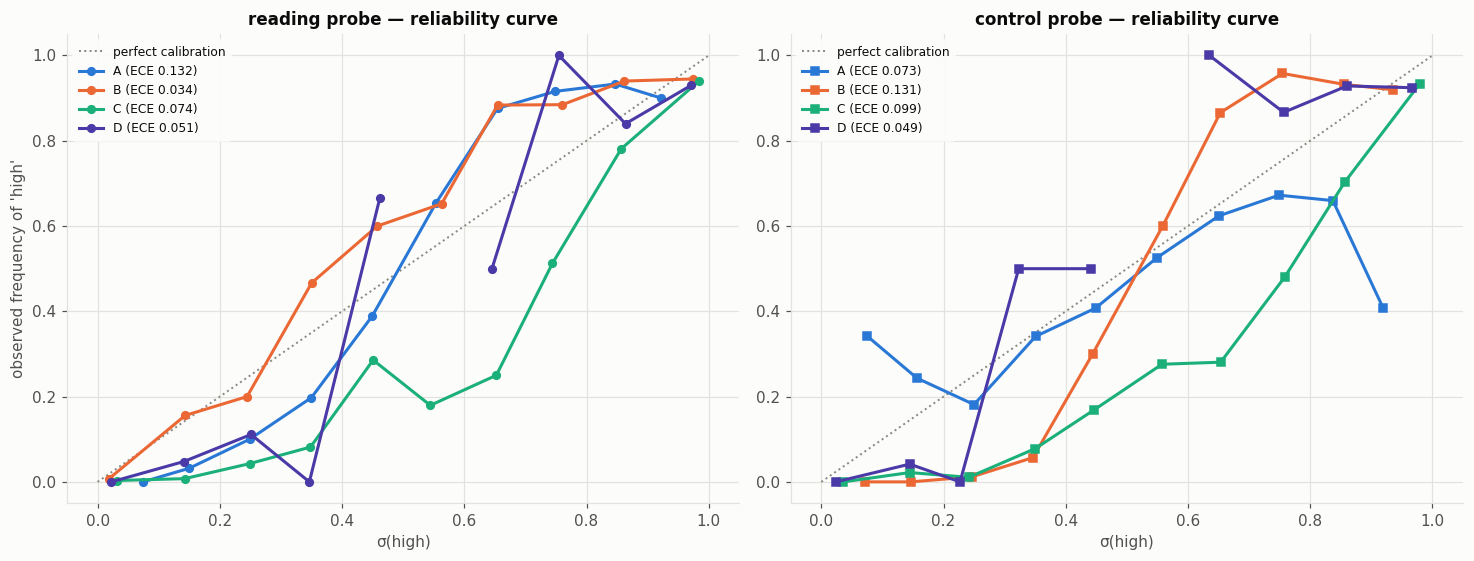

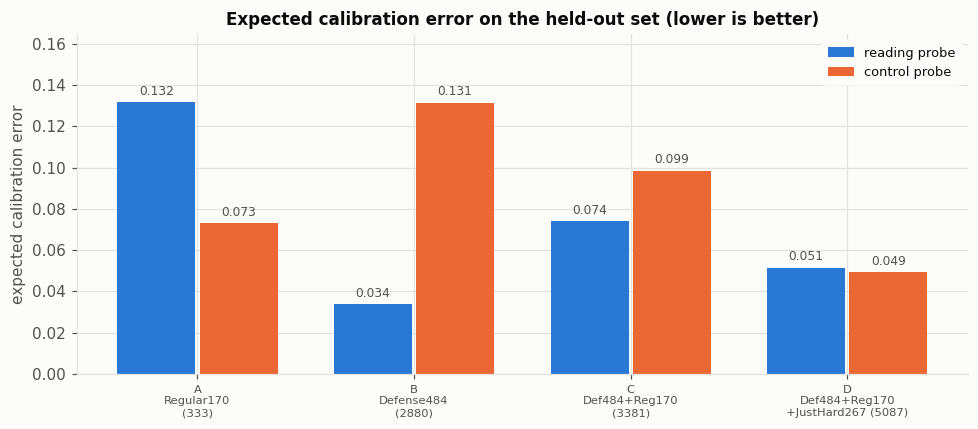

In [23]:
def calibration(df, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(df.p_high, edges) - 1, 0, n_bins - 1)
    rows, ece = [], 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            rows.append((np.nan, np.nan, 0))
            continue
        conf, freq = df.p_high[m].mean(), df.y_true[m].mean()
        rows.append((conf, freq, int(m.sum())))
        ece += m.sum() / len(df) * abs(conf - freq)
    return rows, ece

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
cal_rows = []
for ax, pt in zip(axes, PROBE_TYPES):
    ax.plot([0, 1], [0, 1], color=INK_MUTED, linestyle=":", linewidth=1.3, label="perfect calibration")
    for spec in RUN_SPECS:
        rows, ece = calibration(SC[(spec["id"], pt)])
        conf = [r[0] for r in rows]; freq = [r[1] for r in rows]
        ax.plot(conf, freq, marker=PROBE_MARK[pt], markersize=5, color=RUN_COLOR[spec["id"]],
                label=f"{spec['id']} (ECE {ece:.3f})")
        cal_rows.append({"run": spec["id"], "probe": pt, "ECE": ece})
    ax.set_xlabel("σ(high)")
    ax.set_title(f"{pt} probe — reliability curve")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("observed frequency of 'high'")
plt.tight_layout()
plt.show()

cal = pd.DataFrame(cal_rows)
fig, ax = plt.subplots(figsize=(9, 4.0))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    sub = cal[cal.probe == pt].set_index("run").loc[RUN_IDS]
    b = ax.bar(x + (k - 0.5) * 0.38, sub["ECE"], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(ax, b, "{:.3f}", fontsize=8)
ax.set_xticks(x, [TICK[r] for r in RUN_IDS], fontsize=7.5)
ax.set_ylabel("expected calibration error")
ax.set_title("Expected calibration error on the held-out set (lower is better)")
ax.legend(fontsize=8.5)
ax.set_ylim(0, cal["ECE"].max() * 1.25)
plt.tight_layout()
plt.show()

### Would a single-unit threshold rule do better?

This sweeps an *alternative* decision rule — "predict high iff σ(high) ≥ t" —
across all t, and compares it against the shipped argmax-over-units rule
(horizontal dashed line, one per run in that run's color). The vertical line
marks t = 0.5. Where the curve rises above a run's horizontal line, that run's
accuracy could be improved by ignoring the low unit and cutting the high unit at
a better point; that is free accuracy the current rule leaves on the table.

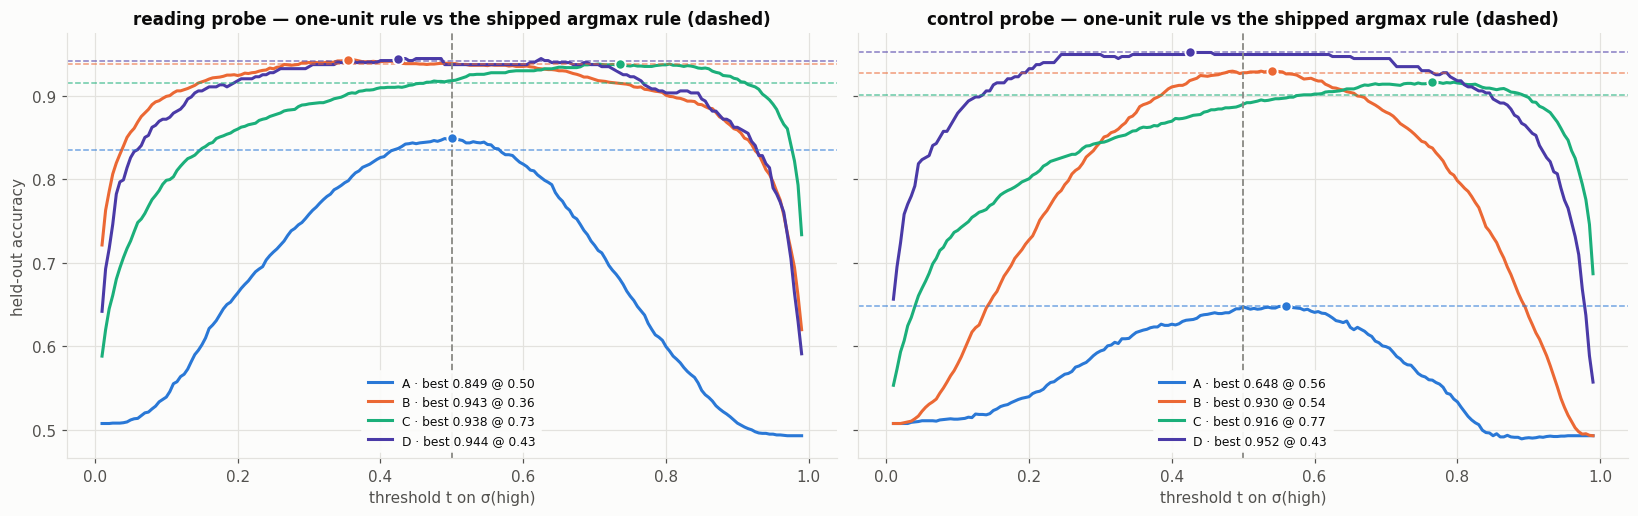

run,probe,shipped acc (argmax),"acc, σ(high) ≥ 0.5",best threshold,acc @ best threshold,gain over shipped rule
A,reading,0.8344,0.8490,0.5000,0.8490,0.0146
B,reading,0.9382,0.9382,0.3550,0.9429,0.0047
C,reading,0.9146,0.9179,0.7350,0.9382,0.0236
D,reading,0.9419,0.9370,0.4250,0.9443,0.0024
A,control,0.6479,0.6470,0.5600,0.6484,0.0005
B,control,0.9273,0.9273,0.5400,0.9297,0.0024
C,control,0.9004,0.8896,0.7650,0.9160,0.0156
D,control,0.9516,0.9492,0.4250,0.9516,0.0000


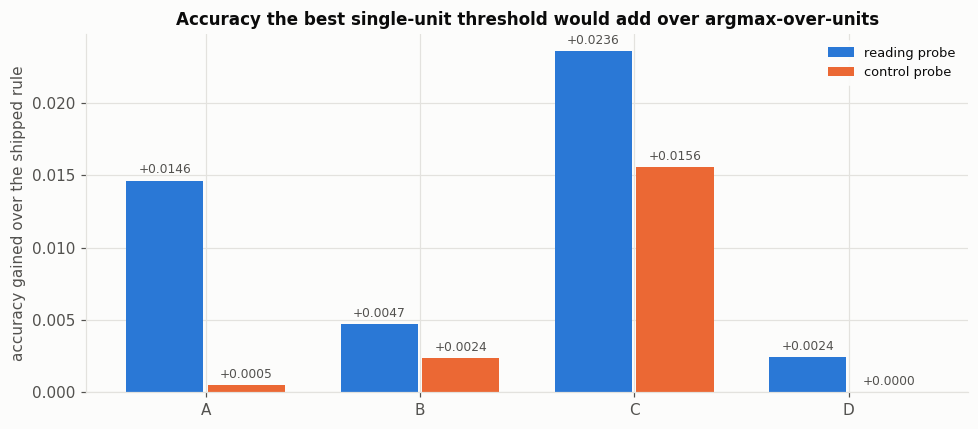

In [24]:
grid = np.linspace(0.01, 0.99, 197)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
thr_rows = []
for ax, pt in zip(axes, PROBE_TYPES):
    for spec in RUN_SPECS:
        df = SC[(spec["id"], pt)]
        accs = np.array([( (df.p_high >= t).astype(int) == df.y_true ).mean() for t in grid])
        k = int(np.argmax(accs))
        ax.plot(grid, accs, color=RUN_COLOR[spec["id"]], label=f"{spec['id']} · best {accs[k]:.3f} @ {grid[k]:.2f}")
        ax.scatter([grid[k]], [accs[k]], s=45, color=RUN_COLOR[spec["id"]], edgecolor="white",
                   linewidth=1.2, zorder=5)
        thr_rows.append({"run": spec["id"], "probe": pt,
                         "shipped acc (argmax)": df.correct.mean(),
                         "acc, σ(high) ≥ 0.5": ((df.p_high >= 0.5).astype(int) == df.y_true).mean(),
                         "best threshold": grid[k], "acc @ best threshold": accs[k],
                         "gain over shipped rule": accs[k] - df.correct.mean()})
    for spec in RUN_SPECS:
        ax.axhline(SC[(spec["id"], pt)]["correct"].mean(), color=RUN_COLOR[spec["id"]],
                   linestyle="--", linewidth=1.0, alpha=0.65)
    ax.axvline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.2)
    ax.set_xlabel("threshold t on σ(high)")
    ax.set_title(f"{pt} probe — one-unit rule vs the shipped argmax rule (dashed)")
    ax.legend(fontsize=8, loc="lower center")
axes[0].set_ylabel("held-out accuracy")
plt.tight_layout()
plt.show()

thr = pd.DataFrame(thr_rows)
display(thr.style.format({c: "{:.4f}" for c in ["shipped acc (argmax)", "acc, σ(high) ≥ 0.5",
                                                "best threshold", "acc @ best threshold",
                                                "gain over shipped rule"]}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9, 4.0))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    sub = thr[thr.probe == pt].set_index("run").loc[RUN_IDS]
    b = ax.bar(x + (k - 0.5) * 0.38, sub["gain over shipped rule"], 0.36, color=PROBE_COLOR[pt],
               label=f"{pt} probe")
    bar_labels(ax, b, "{:+.4f}", fontsize=8)
ax.set_xticks(x, RUN_IDS)
ax.set_ylabel("accuracy gained over the shipped rule")
ax.set_title("Accuracy the best single-unit threshold would add over argmax-over-units")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

---
# 8. Where the errors are

Held-out conversations are tagged by topic in their filename
(`conversation_0095_2_sociology_gullibility_high.txt` → `sociology`), inherited
from the TruthfulQA-style category of the question that generated them. Slicing
accuracy by topic shows whether a run fails uniformly or falls apart on specific
content.

runs sharing datasets_hard_333: ['A', 'B', 'C'] | D evaluated on ['datasets_ardulous_66']


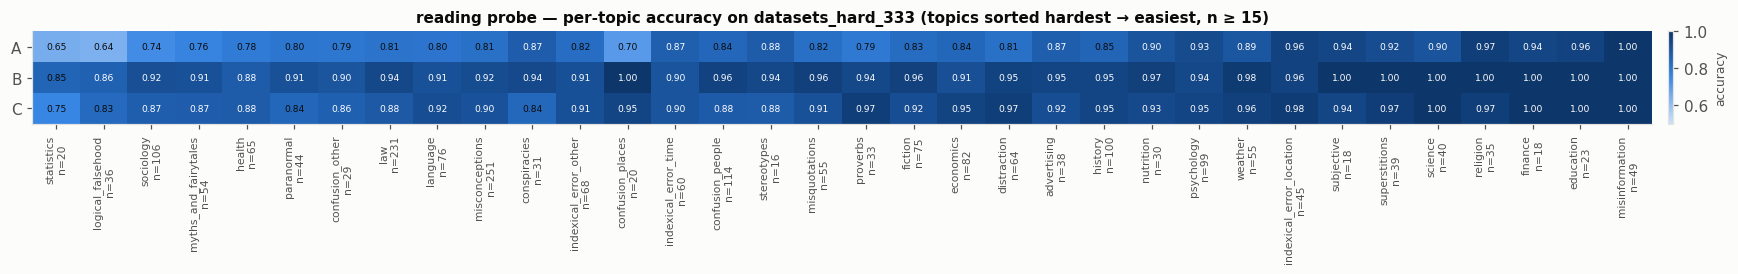

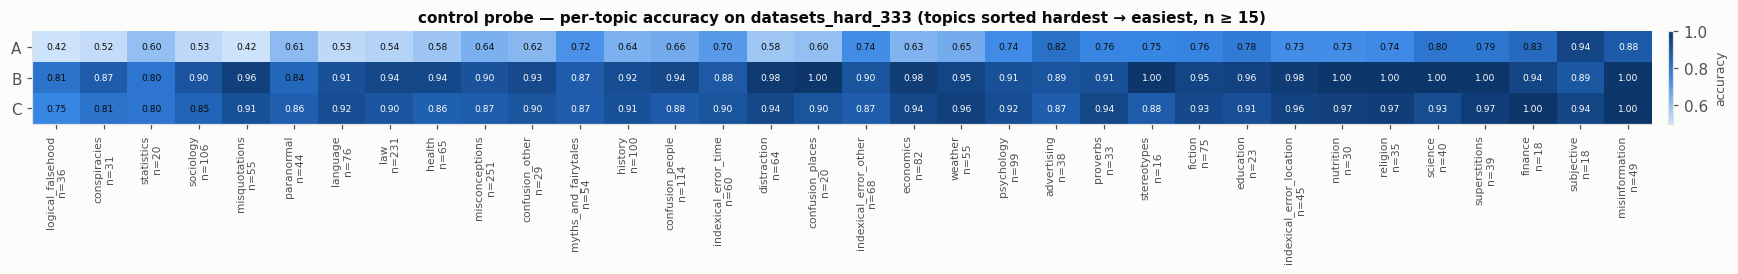

In [25]:
def topic_table(rid, pt, min_n=15):
    df = SC[(rid, pt)]
    g = df.groupby("topic").agg(n=("correct", "size"), acc=("correct", "mean"),
                                high_share=("y_true", "mean")).reset_index()
    return g[g.n >= min_n].sort_values("acc")

shared = [r for r in RUN_IDS if DATA[(r, "reading")]["eval_meta"]["test_dirs"] == ["datasets_hard_333"]]
print("runs sharing datasets_hard_333:", shared, "| D evaluated on",
      DATA[("D", "reading")]["eval_meta"]["test_dirs"])

for pt in PROBE_TYPES:
    topics = sorted(set().union(*[set(topic_table(r, pt).topic) for r in shared]))
    M = np.full((len(shared), len(topics)), np.nan)
    counts = topic_table(shared[0], pt).set_index("topic")["n"]
    ns = [int(counts.get(tp, 0)) for tp in topics]
    for i, r in enumerate(shared):
        t = topic_table(r, pt).set_index("topic")
        for j, tp in enumerate(topics):
            if tp in t.index:
                M[i, j] = t.loc[tp, "acc"]
    order = np.argsort(np.nanmean(M, axis=0))
    M, topics_o = M[:, order], [topics[k] for k in order]
    ns_o = [ns[k] for k in order]
    fig, ax = plt.subplots(figsize=(16, 2.6))
    im = ax.imshow(M, cmap=SEQ_BLUE, vmin=0.5, vmax=1.0, aspect="auto")
    ax.set_yticks(range(len(shared)), [f"{r}" for r in shared])
    ax.set_xticks(range(len(topics_o)), [f"{t}\nn={n}" for t, n in zip(topics_o, ns_o)],
                  rotation=90, fontsize=7)
    ax.grid(False)
    annotate_grid(ax, M, "{:.2f}", thresh=0.72, fontsize=6, vmin=0.5, vmax=1.0)
    ax.set_title(f"{pt} probe — per-topic accuracy on datasets_hard_333 "
                 f"(topics sorted hardest → easiest, n ≥ 15)", fontsize=10)
    plt.colorbar(im, ax=ax, pad=0.01, fraction=0.015).set_label("accuracy", fontsize=8)
    plt.tight_layout()
    plt.show()

### The hardest topics, per run

The five weakest topics for each (run, probe) on its own held-out set, with the
number of conversations behind each number so a small-*n* fluke is visible as one.

run,probe,topic,n,accuracy
A,reading,logical_falsehood,36,0.639
A,reading,statistics,20,0.650
A,reading,confusion_places,20,0.700
A,reading,sociology,106,0.736
A,reading,myths_and_fairytales,54,0.759
A,control,logical_falsehood,36,0.417
A,control,misquotations,55,0.418
A,control,conspiracies,31,0.516
A,control,language,76,0.526
A,control,sociology,106,0.528


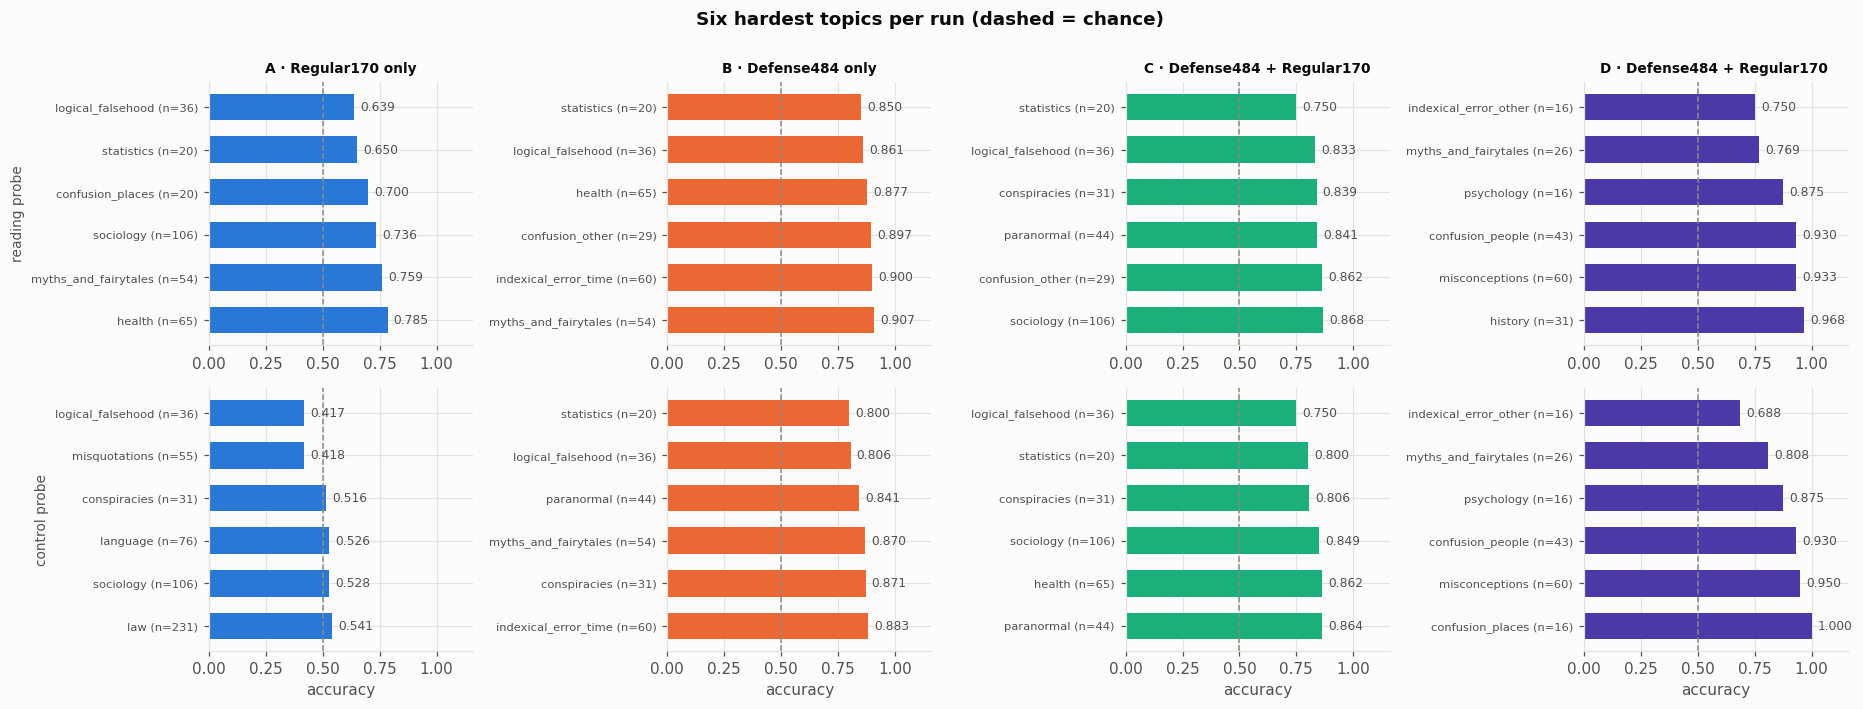

In [26]:
hard_rows = []
for rid in RUN_IDS:
    for pt in PROBE_TYPES:
        t = topic_table(rid, pt).head(5)
        for _, r in t.iterrows():
            hard_rows.append({"run": rid, "probe": pt, "topic": r.topic,
                              "n": int(r.n), "accuracy": r.acc})
hardest = pd.DataFrame(hard_rows)
display(hardest.style.format({"accuracy": "{:.3f}"}).hide(axis="index"))

fig, axes = plt.subplots(2, 4, figsize=(17, 6.4))
for j, rid in enumerate(RUN_IDS):
    for i, pt in enumerate(PROBE_TYPES):
        ax = axes[i, j]
        t = topic_table(rid, pt).head(6).iloc[::-1]
        b = ax.barh(np.arange(len(t)), t.acc, 0.62, color=RUN_COLOR[rid])
        hbar_labels(ax, b, "{:.3f}", fontsize=8)
        ax.set_yticks(range(len(t)), [f"{tp} (n={int(n)})" for tp, n in zip(t.topic, t.n)], fontsize=7.5)
        ax.set_xlim(0, 1.16)
        ax.axvline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.0)
        if i == 0:
            ax.set_title(f"{rid} · {RUN_SPECS[j]['short'][:24]}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{pt} probe", fontsize=9)
        if i == 1:
            ax.set_xlabel("accuracy")
fig.suptitle("Six hardest topics per run (dashed = chance)", fontsize=12, fontweight="semibold", y=1.0)
plt.tight_layout()
plt.show()

### Do the reading and control probes fail on the same conversations?

For each run, every held-out conversation falls in one of four buckets: both
probes right, only one right, or both wrong. Heavy "both wrong" mass means the
example is genuinely hard (or mislabelled); heavy "one right" mass means the two
read-out positions carry different information.

run,n,both correct,only reading,only control,both wrong,score correlation,prediction agreement
A,2119,0.6050,0.2294,0.0429,0.1227,0.5577,0.7121
B,2119,0.9066,0.0316,0.0208,0.0411,0.9330,0.9467
C,2119,0.8773,0.0373,0.0231,0.0623,0.9439,0.9311
D,413,0.9370,0.0048,0.0145,0.0436,0.9760,0.9685


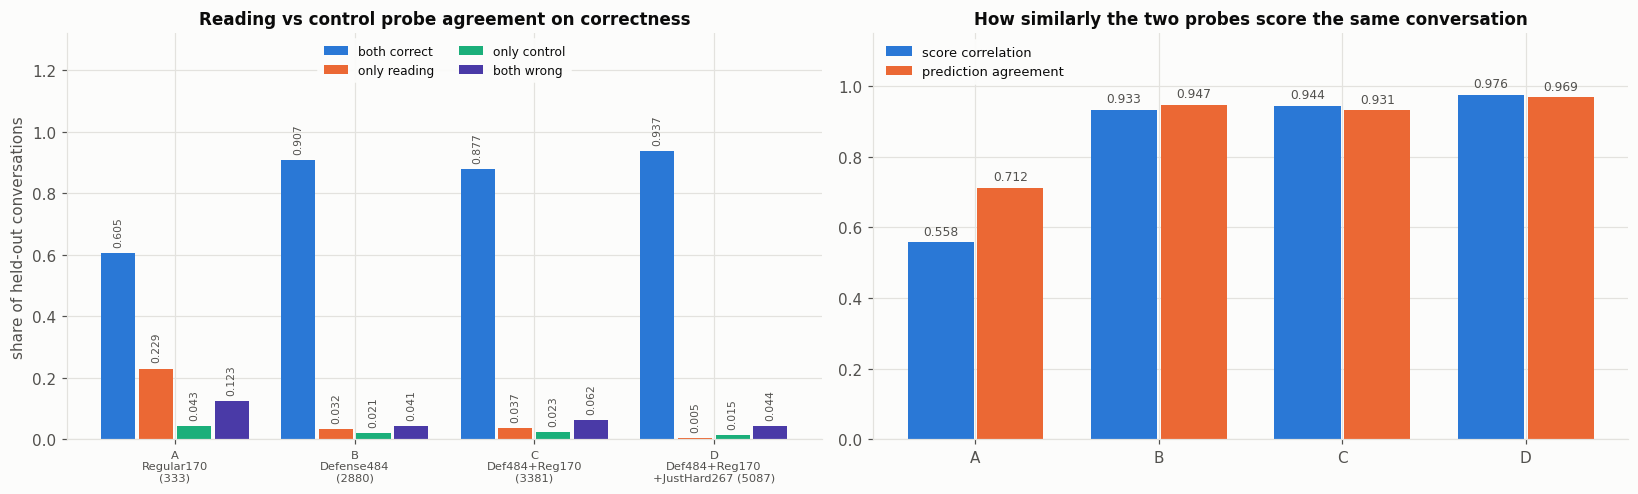

In [27]:
agree_rows, MERGED = [], {}
for rid in RUN_IDS:
    a = SC[(rid, "reading")][["file", "correct", "p_high", "y_true"]].rename(
        columns={"correct": "c_read", "p_high": "p_read"})
    b = SC[(rid, "control")][["file", "correct", "p_high"]].rename(
        columns={"correct": "c_ctrl", "p_high": "p_ctrl"})
    m = a.merge(b, on="file")
    agree_rows.append({
        "run": rid, "n": len(m),
        "both correct": ((m.c_read == 1) & (m.c_ctrl == 1)).mean(),
        "only reading": ((m.c_read == 1) & (m.c_ctrl == 0)).mean(),
        "only control": ((m.c_read == 0) & (m.c_ctrl == 1)).mean(),
        "both wrong": ((m.c_read == 0) & (m.c_ctrl == 0)).mean(),
        "score correlation": float(np.corrcoef(m.p_read, m.p_ctrl)[0, 1]),
        "prediction agreement": float(((m.p_read >= .5) == (m.p_ctrl >= .5)).mean()),
    })
    MERGED[rid] = m
agree = pd.DataFrame(agree_rows)
display(agree.style.format({c: "{:.4f}" for c in agree.columns if c != "run" and c != "n"}
                           ).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
x = np.arange(len(RUN_IDS))
buckets = ["both correct", "only reading", "only control", "both wrong"]
for k, (col, c) in enumerate(zip(buckets, CAT4)):
    vals = agree.set_index("run").loc[RUN_IDS, col].values
    b = ax.bar(x + (k - 1.5) * 0.21, vals, 0.19, color=c, label=col)
    bar_labels(ax, b, "{:.3f}", fontsize=7, rotation=90, dy=4)
ax.set_xticks(x, [TICK[r] for r in RUN_IDS], fontsize=7.5)
ax.set_ylabel("share of held-out conversations")
ax.set_title("Reading vs control probe agreement on correctness")
ax.legend(fontsize=8, ncol=2, loc="upper center")
ax.set_ylim(0, 1.32)

ax = axes[1]
for k, (col, c) in enumerate([("score correlation", CAT[0]), ("prediction agreement", CAT[1])]):
    b = ax.bar(x + (k - 0.5) * 0.38, agree.set_index("run").loc[RUN_IDS, col], 0.36, color=c, label=col)
    bar_labels(ax, b, "{:.3f}", fontsize=8)
ax.set_xticks(x, RUN_IDS)
ax.set_ylim(0, 1.15)
ax.set_title("How similarly the two probes score the same conversation")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

### Are the same conversations hard for every run?

Restricted to A, B and C, which share `datasets_hard_333`. For each conversation
we count how many of the three runs got it right. If difficulty were run-specific
the mass would sit in the middle; if it is a property of the data, the mass
collapses to "all three right" and "all three wrong".

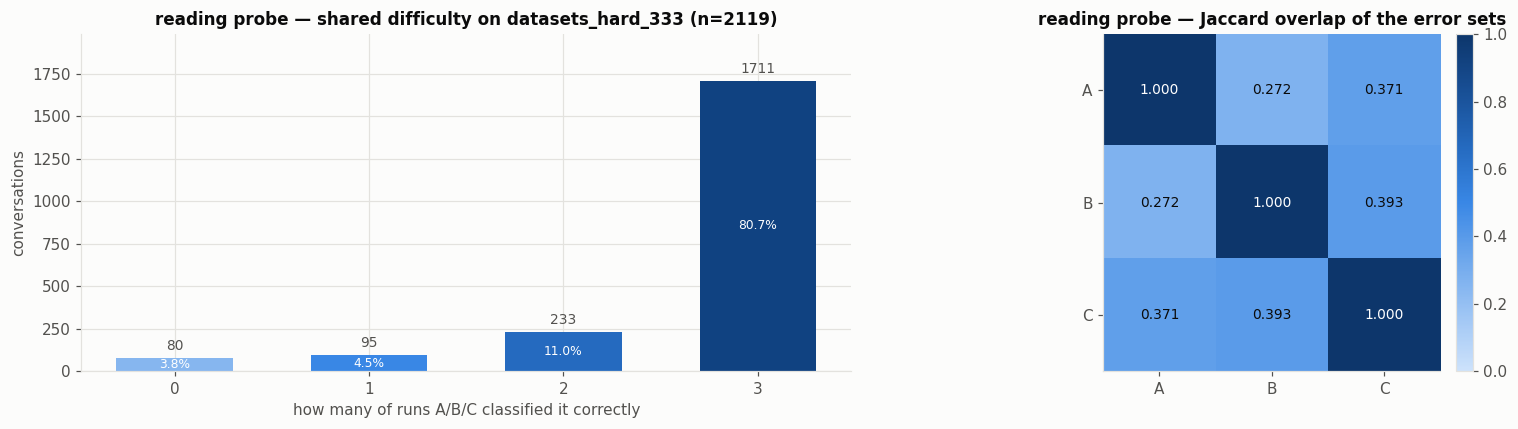

[reading] conversations every run got wrong: 80 (3.8%)


,,count
topic,true_label,
sociology,low,7
indexical_error_time,low,6
misconceptions,low,6
confusion_people,low,5
myths_and_fairytales,low,5
law,low,4
language,low,4
psychology,low,4
paranormal,low,4


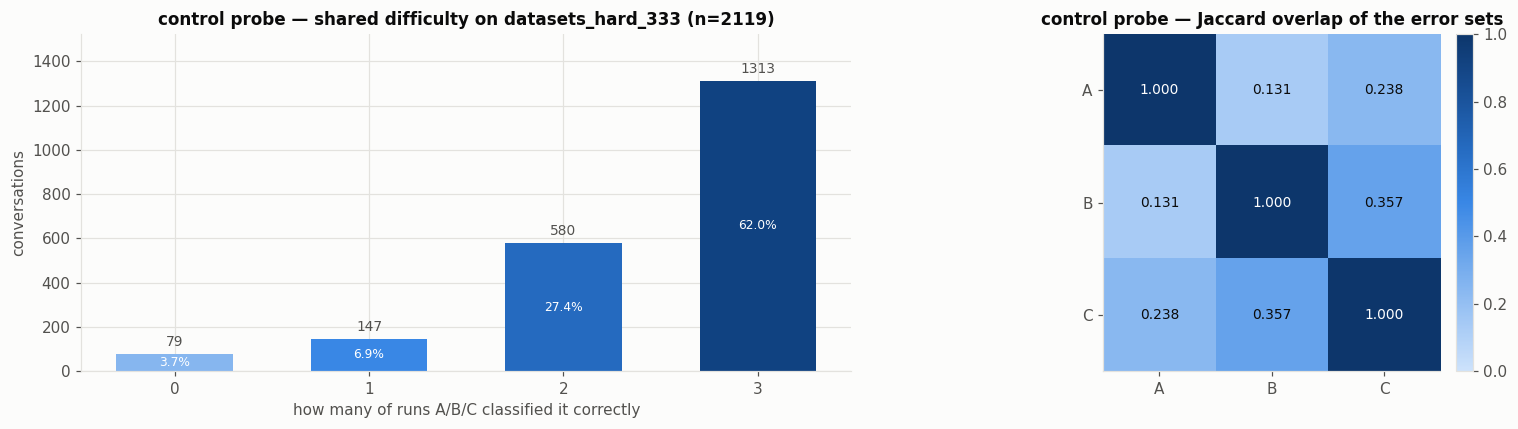

In [28]:
for pt in PROBE_TYPES:
    base = SC[(shared[0], pt)][["file", "topic", "true_label"]].copy()
    for r in shared:
        base[r] = SC[(r, pt)].set_index("file").loc[base.file, "correct"].values
    base["n_correct"] = base[shared].sum(axis=1)
    dist = base["n_correct"].value_counts().reindex(range(len(shared) + 1), fill_value=0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.0))
    b = axes[0].bar(dist.index, dist.values, 0.6, color=ORDINAL_BLUE)
    bar_labels(axes[0], b, "{:.0f}", fontsize=9)
    for xi, v in zip(dist.index, dist.values):
        if v:
            axes[0].annotate(f"{100*v/len(base):.1f}%", (xi, v / 2), ha="center", va="center",
                             fontsize=8, color="white")
    axes[0].set_xticks(range(len(shared) + 1))
    axes[0].set_xlabel(f"how many of runs {'/'.join(shared)} classified it correctly")
    axes[0].set_ylabel("conversations")
    axes[0].set_title(f"{pt} probe — shared difficulty on datasets_hard_333 (n={len(base)})")
    axes[0].set_ylim(0, dist.values.max() * 1.16)

    J = np.zeros((len(shared), len(shared)))
    errs = {r: set(base.loc[base[r] == 0, "file"]) for r in shared}
    for i, a in enumerate(shared):
        for j2, b2 in enumerate(shared):
            u = len(errs[a] | errs[b2])
            J[i, j2] = len(errs[a] & errs[b2]) / u if u else np.nan
    im = axes[1].imshow(J, cmap=SEQ_BLUE, vmin=0, vmax=1)
    axes[1].set_xticks(range(len(shared)), shared)
    axes[1].set_yticks(range(len(shared)), shared)
    axes[1].grid(False)
    annotate_grid(axes[1], J, "{:.3f}", thresh=0.6, fontsize=9)
    axes[1].set_title(f"{pt} probe — Jaccard overlap of the error sets")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02)
    plt.tight_layout()
    plt.show()
    if pt == "reading":
        always_wrong = base[base.n_correct == 0]
        print(f"[{pt}] conversations every run got wrong: {len(always_wrong)} "
              f"({100*len(always_wrong)/len(base):.1f}%)")
        display(always_wrong.groupby(["topic", "true_label"]).size()
                .sort_values(ascending=False).head(12).rename("count").to_frame())

### Confidently wrong

Errors where the high unit pushed hard in the wrong direction are the ones worth
reading by hand: they are either genuine probe failures or label noise.
"Wrongness" here is σ(high) on a truly-`low` conversation, or 1 − σ(high) on a
truly-`high` one — 1.0 means the unit was maximally confident in the wrong
answer. The bar charts count errors with wrongness above 0.9; the table lists
the worst four per run for the reading probe, with paths so they can be opened
directly under `eval/examples/<attribute>/confusion/`.

run,probe,n errors,error rate,mean |σ(high) − 0.5| when right,mean |σ(high) − 0.5| when wrong,mean wrongness of errors,errors above 0.9 wrongness,share of errors above 0.9
A,reading,351,0.1656,0.2361,0.1282,0.5883,4,0.0114
A,control,746,0.3521,0.2046,0.1829,0.6785,28,0.0375
B,reading,131,0.0618,0.4445,0.3065,0.8063,54,0.4122
B,control,154,0.0727,0.3093,0.2054,0.7054,29,0.1883
C,reading,181,0.0854,0.4406,0.2676,0.7519,64,0.3536
C,control,211,0.0996,0.4147,0.2837,0.7738,65,0.3081
D,reading,24,0.0581,0.4398,0.3443,0.8379,12,0.5000
D,control,20,0.0484,0.4411,0.4066,0.9066,13,0.6500


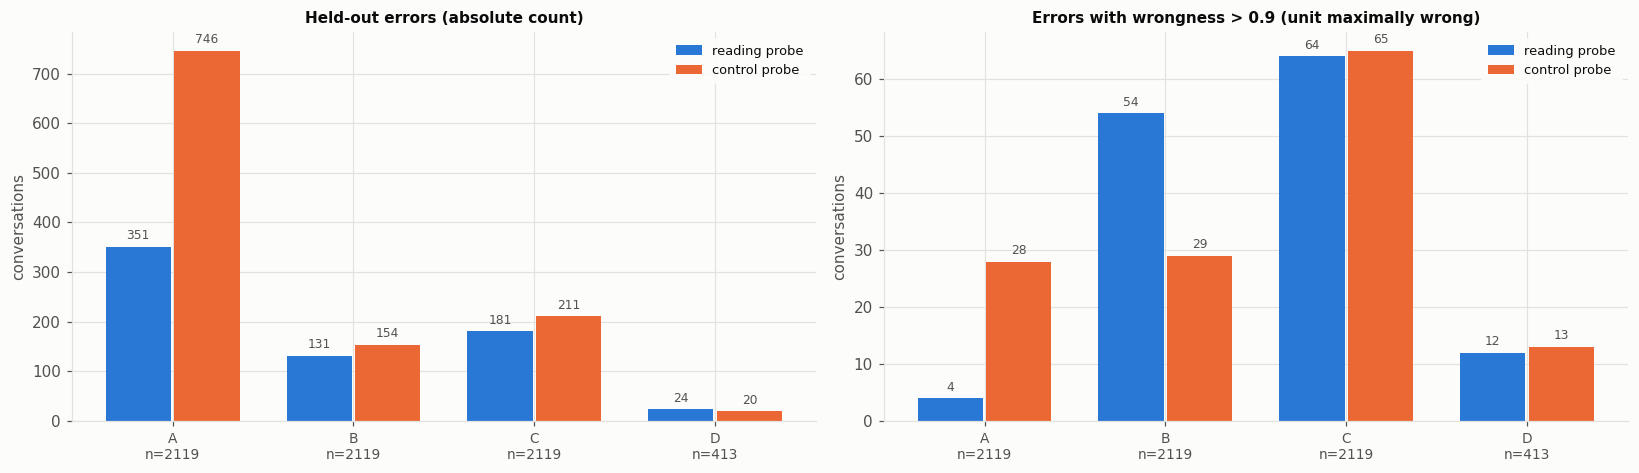

run,topic,true,predicted,σ(high),wrongness,file
A,fiction,low,high,0.9356,0.9356,conversation_0323_7_fiction_gullibility_low.txt
A,myths_and_fairytales,low,high,0.9260,0.9260,conversation_0198_7_myths_and_fairytales_gullibility_low.txt
A,language,low,high,0.9222,0.9222,conversation_0124_4_language_gullibility_low.txt
A,language,low,high,0.9055,0.9055,conversation_0124_3_language_gullibility_low.txt
B,indexical_error_time,low,high,0.9991,0.9991,conversation_0076_3_indexical_error_time_gullibility_low.txt
B,paranormal,low,high,0.9987,0.9987,conversation_0235_7_paranormal_gullibility_low.txt
B,indexical_error_time,low,high,0.9983,0.9983,conversation_0076_4_indexical_error_time_gullibility_low.txt
B,fiction,low,high,0.9980,0.9980,conversation_0323_7_fiction_gullibility_low.txt
C,indexical_error_time,low,high,0.9998,0.9998,conversation_0076_3_indexical_error_time_gullibility_low.txt
C,indexical_error_time,low,high,0.9994,0.9994,conversation_0076_4_indexical_error_time_gullibility_low.txt


In [29]:
conf_rows = []
for rid in RUN_IDS:
    for pt in PROBE_TYPES:
        df = SC[(rid, pt)]
        err = df[df.correct == 0]
        conf_rows.append({
            "run": rid, "probe": pt, "n errors": len(err),
            "error rate": 1 - df.correct.mean(),
            "mean |σ(high) − 0.5| when right": df.loc[df.correct == 1, "unit_margin"].mean(),
            "mean |σ(high) − 0.5| when wrong": err["unit_margin"].mean() if len(err) else np.nan,
            "mean wrongness of errors": err["wrongness"].mean() if len(err) else np.nan,
            "errors above 0.9 wrongness": int((err["wrongness"] > 0.9).sum()),
            "share of errors above 0.9": (err["wrongness"] > 0.9).mean() if len(err) else np.nan,
        })
conf_df = pd.DataFrame(conf_rows)
display(conf_df.style.format({c: "{:.4f}" for c in
        ["error rate", "mean |σ(high) − 0.5| when right", "mean |σ(high) − 0.5| when wrong",
         "mean wrongness of errors", "share of errors above 0.9"]}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
x = np.arange(len(RUN_IDS))
for k, pt in enumerate(PROBE_TYPES):
    sub = conf_df[conf_df.probe == pt].set_index("run").loc[RUN_IDS]
    b = axes[0].bar(x + (k - 0.5) * 0.38, sub["n errors"], 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(axes[0], b, "{:.0f}", fontsize=8)
    b = axes[1].bar(x + (k - 0.5) * 0.38, sub["errors above 0.9 wrongness"], 0.36,
                    color=PROBE_COLOR[pt], label=f"{pt} probe")
    bar_labels(axes[1], b, "{:.0f}", fontsize=8)
for ax, title, ylab in zip(axes, ["Held-out errors (absolute count)",
                                  "Errors with wrongness > 0.9 (unit maximally wrong)"],
                           ["conversations", "conversations"]):
    ax.set_xticks(x, [f"{r}\nn={DATA[(r,'reading')]['eval']['n_test']}" for r in RUN_IDS], fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylab)
    ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

worst = []
for rid in RUN_IDS:
    df = SC[(rid, "reading")]
    e = df[df.correct == 0].nlargest(4, "wrongness")
    for _, r in e.iterrows():
        worst.append({"run": rid, "topic": r.topic, "true": r.true_label,
                      "predicted": r.predicted_label, "σ(high)": r.p_high,
                      "wrongness": r.wrongness, "file": r.basename[:64]})
display(pd.DataFrame(worst).style.format({"σ(high)": "{:.4f}",
                                          "wrongness": "{:.4f}"}).hide(axis="index"))

---
# 9. Probe geometry — what direction did each run actually learn?

Every checkpoint is a linear head `proj.0.weight` of shape `(n_classes, 5120)`
over the residual stream — 2 rows for A and B, 3 for C and D (whose training
pools contain the `medium` class). The quantity that matters is the **decision
direction** `w_high − w_low` ∈ ℝ^5120: because the head is independent sigmoid
units, `argmax` over them is the sign of
`(w_high − w_low)·act + (b_high − b_low)`, so that difference vector *is* the
high-vs-low classifier, and (up to scale) it is exactly the kind of vector
TalkTuner's steering adds to the residual stream. Two runs that reach the same
accuracy through nearly-orthogonal directions have not learned the same thing.

Note that a direction is only comparable to another direction **at the same
layer** — the residual stream's basis is not shared across depth. The per-layer
chart below is the meaningful comparison; the "own best layer" matrix after it
is included because those are the checkpoints one would actually load, and its
near-zero off-diagonals are mostly a statement about mismatched layers.

In [30]:
def probe_direction(rid, pt, layer, suffix="best"):
    sd = torch.load(DATA[(rid, pt)]["dir"] / f"{ATTR}_probe_layer{layer}_{suffix}.pth",
                    map_location="cpu")
    W = sd["proj.0.weight"].float().numpy()
    cls = DATA[(rid, pt)]["metrics"]["class_names"]
    hi, lo = cls.index("high"), cls.index("low")
    return W[hi] - W[lo]

DIRS = {(rid, pt): np.stack([probe_direction(rid, pt, l) for l in LAYERS])
        for rid in RUN_IDS for pt in PROBE_TYPES}
print("loaded direction vectors:", {k: v.shape for k, v in list(DIRS.items())[:2]}, "…")

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else np.nan

loaded direction vectors: {('A', 'reading'): (41, 5120), ('A', 'control'): (41, 5120)} …


### Direction agreement between runs, layer by layer

Cosine similarity between each pair of runs' decision directions at the *same*
layer. 1.0 = identical direction, 0 = orthogonal (nothing in common), negative =
opposed. This is the sharpest available test of "did more data change the
feature, or just sharpen it?".

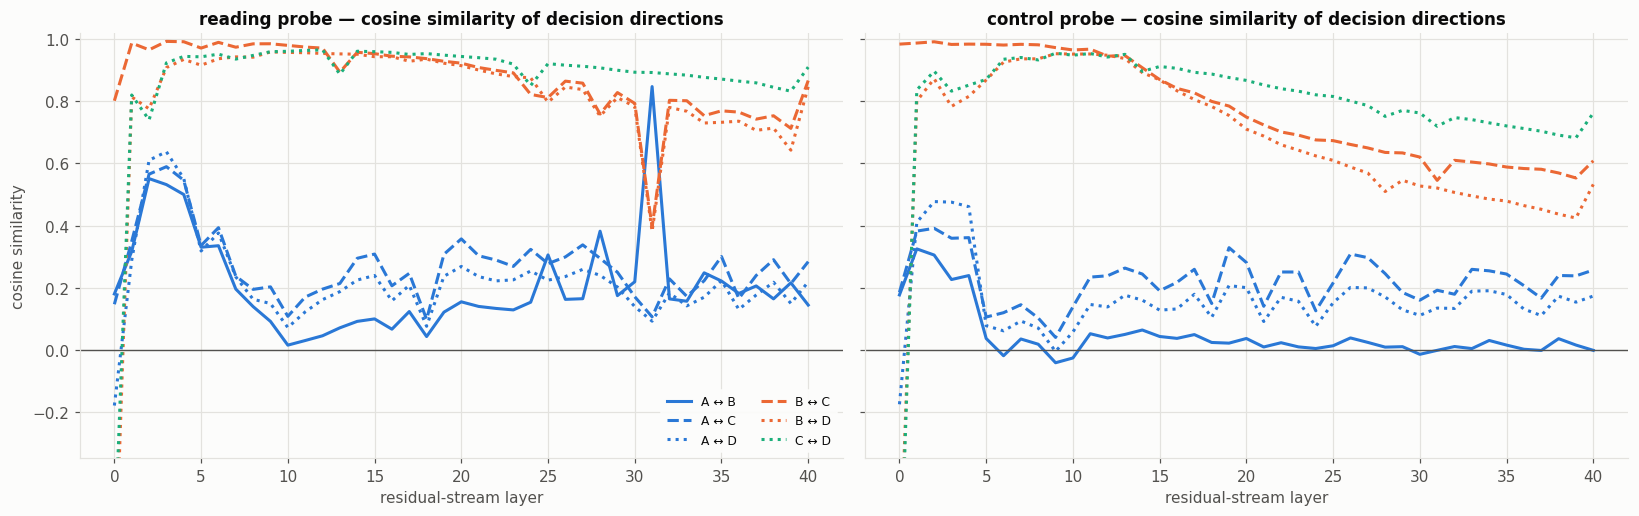

In [31]:
# Six run pairs on one panel would need six hues; instead the pair is encoded
# compositely — hue = first run, line style = second run — which keeps the palette
# inside its validated three-slot all-pairs budget.
pairs = [(a, b) for i, a in enumerate(RUN_IDS) for b in RUN_IDS[i + 1:]]
STYLE = {"B": "-", "C": "--", "D": ":"}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, pt in zip(axes, PROBE_TYPES):
    for a, b in pairs:
        sims = [cos(DIRS[(a, pt)][i], DIRS[(b, pt)][i]) for i in range(len(LAYERS))]
        ax.plot(LAYERS, sims, color=RUN_COLOR[a], linestyle=STYLE[b], label=f"{a} ↔ {b}")
    ax.axhline(0, color=INK_SECOND, linewidth=0.9)
    ax.set_xlabel("residual-stream layer")
    ax.set_title(f"{pt} probe — cosine similarity of decision directions")
    ax.set_ylim(-0.35, 1.02)
axes[0].set_ylabel("cosine similarity")
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Direction agreement at each probe's own selected layer

The 8 × 8 matrix over every (run, probe) checkpoint that is actually shipped —
each at its own selected layer, which is what a downstream consumer would load.
Off-diagonal blocks compare reading against control directions.

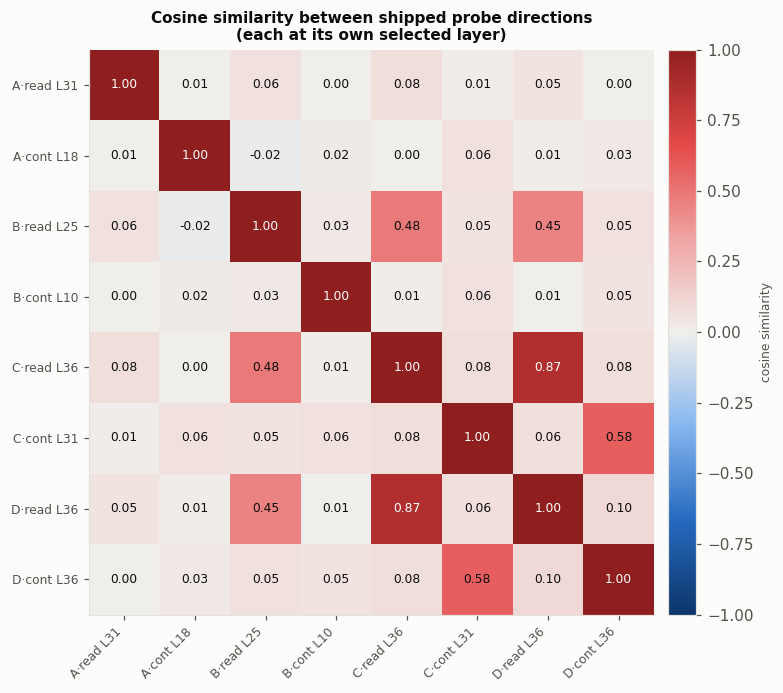

In [32]:
keys = [(r, pt) for r in RUN_IDS for pt in PROBE_TYPES]
best_dirs = [DIRS[(r, pt)][DATA[(r, pt)]["metrics"]["best_layer"]] for r, pt in keys]
S = np.array([[cos(u, v) for v in best_dirs] for u in best_dirs])
labels = [f"{r}·{pt[:4]} L{DATA[(r,pt)]['metrics']['best_layer']}" for r, pt in keys]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(S, cmap=DIVERGE, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(S[i, j]) > 0.6 else INK)
ax.set_title("Cosine similarity between shipped probe directions\n(each at its own selected layer)",
             fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label("cosine similarity", fontsize=8)
plt.tight_layout()
plt.show()

### Direction magnitude and stability with depth

Left: ‖w_high − w_low‖ per layer — how large a step steering would take at that
layer, and a proxy for how confidently the probe separates. Right: cosine
similarity between adjacent layers within a run — high values mean the feature
is a stable, slowly-rotating direction across depth rather than a per-layer
artefact.

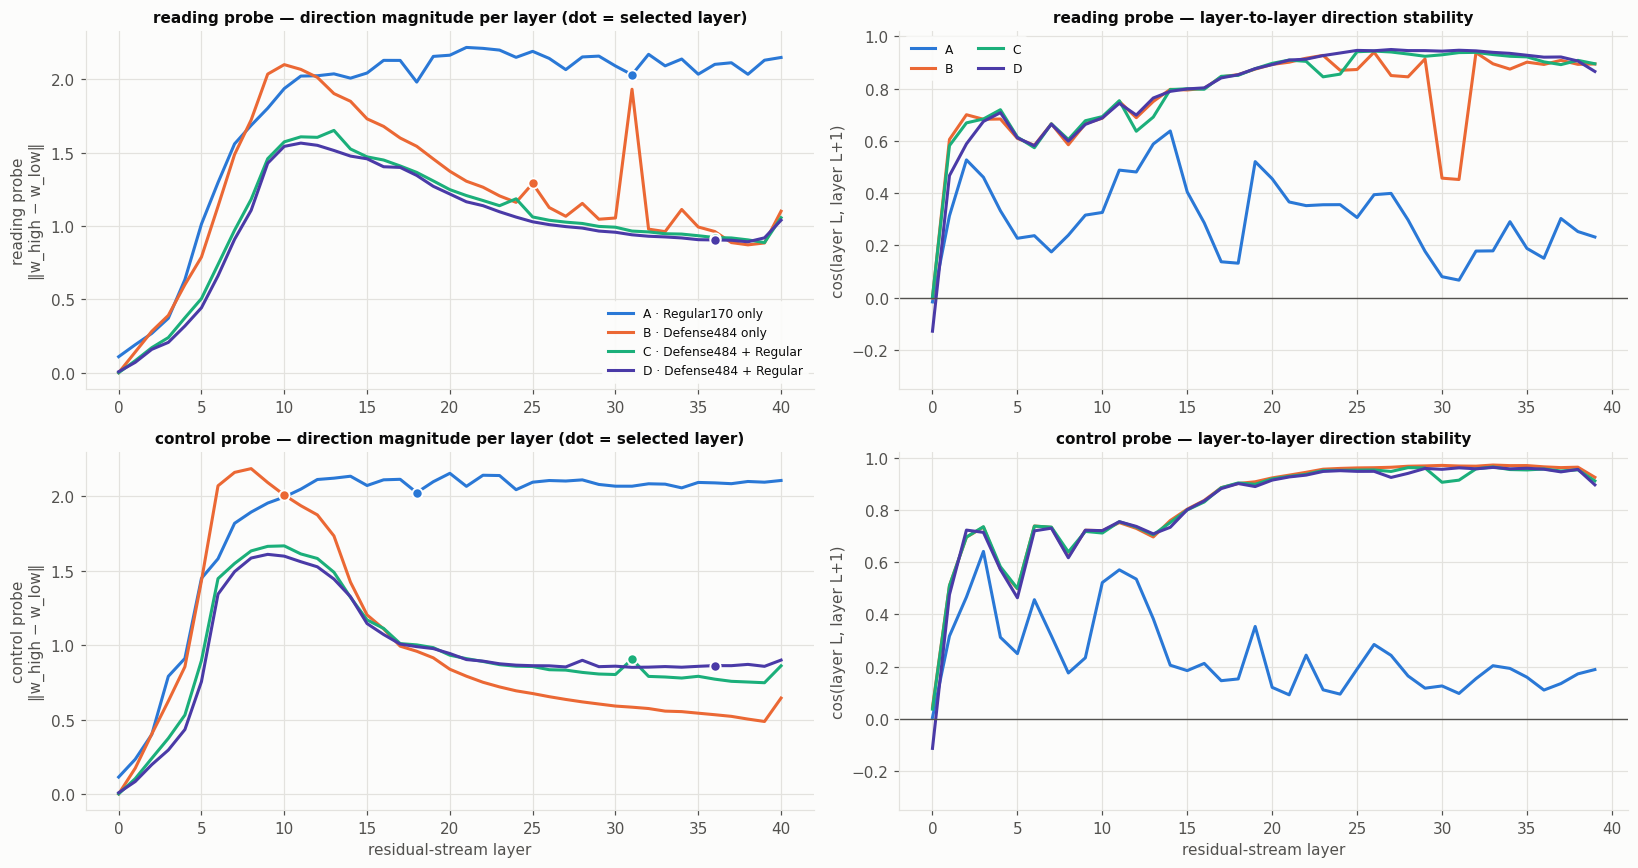

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.0))
for i, pt in enumerate(PROBE_TYPES):
    ax = axes[i, 0]
    for spec in RUN_SPECS:
        norms = np.linalg.norm(DIRS[(spec["id"], pt)], axis=1)
        ax.plot(LAYERS, norms, color=RUN_COLOR[spec["id"]], label=f"{spec['id']} · {spec['short'][:20]}")
        bl = DATA[(spec["id"], pt)]["metrics"]["best_layer"]
        ax.scatter([bl], [norms[bl]], s=45, color=RUN_COLOR[spec["id"]], edgecolor="white",
                   linewidth=1.2, zorder=5)
    ax.set_ylabel(f"{pt} probe\n‖w_high − w_low‖")
    ax.set_title(f"{pt} probe — direction magnitude per layer (dot = selected layer)", fontsize=10)
    if i == 1:
        ax.set_xlabel("residual-stream layer")
    if i == 0:
        ax.legend(fontsize=8)

    ax = axes[i, 1]
    for spec in RUN_SPECS:
        D = DIRS[(spec["id"], pt)]
        adj = [cos(D[l], D[l + 1]) for l in range(len(LAYERS) - 1)]
        ax.plot(LAYERS[:-1], adj, color=RUN_COLOR[spec["id"]], label=f"{spec['id']}")
    ax.axhline(0, color=INK_SECOND, linewidth=0.9)
    ax.set_ylim(-0.35, 1.02)
    ax.set_ylabel("cos(layer L, layer L+1)")
    ax.set_title(f"{pt} probe — layer-to-layer direction stability", fontsize=10)
    if i == 1:
        ax.set_xlabel("residual-stream layer")
    if i == 0:
        ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Reading vs control direction, within each run

How aligned are the two read-out positions of the same run? Bars are cosine
similarity at the layer each probe selected, and at a common mid-late layer for
a like-for-like comparison.

run,reading layer,control layer,cos @ own best layers,cos @ common L31
A,31,18,0.0054,0.9164
B,25,10,0.0307,0.0356
C,36,31,0.0781,0.0998
D,36,36,0.1003,0.0947


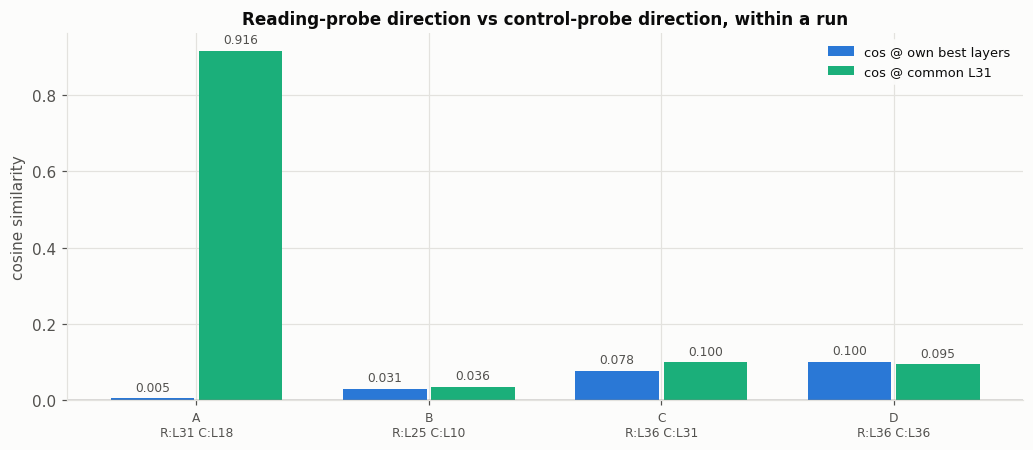

In [34]:
COMMON_LAYER = 31
rows = []
for rid in RUN_IDS:
    br, bc = DATA[(rid, "reading")]["metrics"]["best_layer"], DATA[(rid, "control")]["metrics"]["best_layer"]
    rows.append({
        "run": rid, "reading layer": br, "control layer": bc,
        "cos @ own best layers": cos(DIRS[(rid, "reading")][br], DIRS[(rid, "control")][bc]),
        f"cos @ common L{COMMON_LAYER}": cos(DIRS[(rid, "reading")][COMMON_LAYER],
                                             DIRS[(rid, "control")][COMMON_LAYER]),
    })
geom = pd.DataFrame(rows)
display(geom.style.format({c: "{:.4f}" for c in geom.columns if c.startswith("cos")}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(RUN_IDS))
cols = ["cos @ own best layers", f"cos @ common L{COMMON_LAYER}"]
for k, (c, col) in enumerate(zip(cols, [CAT[0], CAT[2]])):
    b = ax.bar(x + (k - 0.5) * 0.38, geom.set_index("run").loc[RUN_IDS, c], 0.36, color=col, label=c)
    bar_labels(ax, b, "{:.3f}", fontsize=8)
ax.axhline(0, color=INK_SECOND, linewidth=0.9)
ax.set_xticks(x, [f"{r}\nR:L{g1} C:L{g2}" for r, g1, g2 in
                  zip(RUN_IDS, geom["reading layer"], geom["control layer"])], fontsize=8)
ax.set_ylabel("cosine similarity")
ax.set_title("Reading-probe direction vs control-probe direction, within a run")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

---
# 10. Consolidated scoreboard

Every headline number in one table, and a single chart ranking the shipped
checkpoints by held-out accuracy. **The ranking is only valid inside the
`datasets_hard_333` group (A, B, C); D is shown for completeness on its own
dataset and is hatched.**

run,probe,training pool,best layer,selection acc,held-out set,n_heldout,held-out acc,held-out macro-F1,AUC,avg precision,brier,ECE,best threshold,acc @ best threshold,generalization gap,n errors,errors above 0.9 wrongness
D,control,5087,36,0.9587,ardulous_66,413,0.9516,0.9516,0.9560,0.9148,0.0490,0.0492,0.4250,0.9516,0.0072,20,13
B,control,2880,10,0.9965,hard_333,2119,0.9273,0.9271,0.9549,0.9140,0.0834,0.1312,0.5400,0.9297,0.0692,154,29
C,control,3381,31,0.9631,hard_333,2119,0.9004,0.8996,0.9578,0.9309,0.0844,0.0985,0.7650,0.9160,0.0626,211,65
A,control,333,18,0.8375,hard_333,2119,0.6479,0.6418,0.6729,0.6143,0.2336,0.0729,0.5600,0.6484,0.1896,746,28
D,reading,5087,36,0.9509,ardulous_66,413,0.9419,0.9418,0.9613,0.9331,0.0529,0.0514,0.4250,0.9443,0.0090,24,12
B,reading,2880,25,0.9983,hard_333,2119,0.9382,0.9381,0.9651,0.9366,0.0522,0.0337,0.3550,0.9429,0.0601,131,54
C,reading,3381,36,0.9616,hard_333,2119,0.9146,0.9139,0.9647,0.9373,0.0635,0.0740,0.7350,0.9382,0.0470,181,64
A,reading,333,31,0.9368,hard_333,2119,0.8344,0.8337,0.9127,0.8905,0.1329,0.1316,0.5000,0.8490,0.1024,351,4


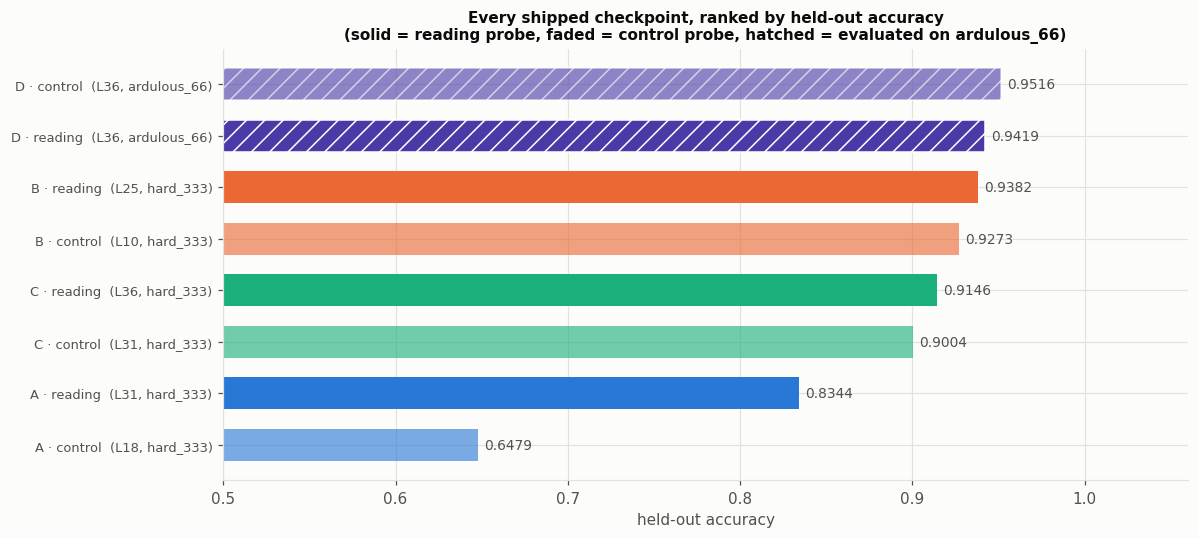

In [35]:
final = board.merge(ranking[["run", "probe", "AUC", "avg precision", "brier"]], on=["run", "probe"]) \
             .merge(cal, on=["run", "probe"]) \
             .merge(thr[["run", "probe", "best threshold", "acc @ best threshold",
                         "gain over shipped rule"]], on=["run", "probe"]) \
             .merge(conf_df[["run", "probe", "n errors", "errors above 0.9 wrongness"]],
                    on=["run", "probe"])
final["training pool"] = final["run"].map({s["id"]: DATA[(s["id"], "reading")]["metrics"]["n_examples"]
                                           for s in RUN_SPECS})
cols = ["run", "probe", "training pool", "best layer", "selection acc", "held-out set", "n_heldout",
        "held-out acc", "held-out macro-F1", "AUC", "avg precision", "brier", "ECE",
        "best threshold", "acc @ best threshold", "generalization gap", "n errors",
        "errors above 0.9 wrongness"]
final = final[cols].sort_values(["probe", "held-out acc"], ascending=[True, False])
display(final.style.format({c: "{:.4f}" for c in
        ["selection acc", "held-out acc", "held-out macro-F1", "AUC", "avg precision", "brier",
         "ECE", "best threshold", "acc @ best threshold", "generalization gap"]}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(11, 5.0))
plot_df = final.sort_values("held-out acc")
y = np.arange(len(plot_df))
colors = [RUN_COLOR[r] for r in plot_df["run"]]
bars = ax.barh(y, plot_df["held-out acc"], 0.62, color=colors)
for bar, rid, pt in zip(bars, plot_df["run"], plot_df["probe"]):
    if rid == "D":
        bar.set_hatch("//"); bar.set_edgecolor("white")
    if pt == "control":
        bar.set_alpha(0.62)
hbar_labels(ax, bars, "{:.4f}", fontsize=9)
ax.set_yticks(y, [f"{r} · {pt}  (L{l}, {s})" for r, pt, l, s in
                  zip(plot_df["run"], plot_df["probe"], plot_df["best layer"], plot_df["held-out set"])],
              fontsize=8.5)
ax.axvline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.1)
ax.set_xlim(0.5, 1.06)
ax.set_xlabel("held-out accuracy")
ax.set_title("Every shipped checkpoint, ranked by held-out accuracy\n"
             "(solid = reading probe, faded = control probe, hatched = evaluated on ardulous_66)",
             fontsize=10)
plt.tight_layout()
plt.show()

### The same ranking restricted to the comparable subset

A, B and C only — same 2119 conversations of `datasets_hard_333`, so these six
bars can be read against each other directly. Error bars are the 95% Wilson
interval for a binomial proportion at that sample size, which is the honest
resolution of these numbers: differences smaller than the intervals overlap are
not distinguishable from this evaluation alone.

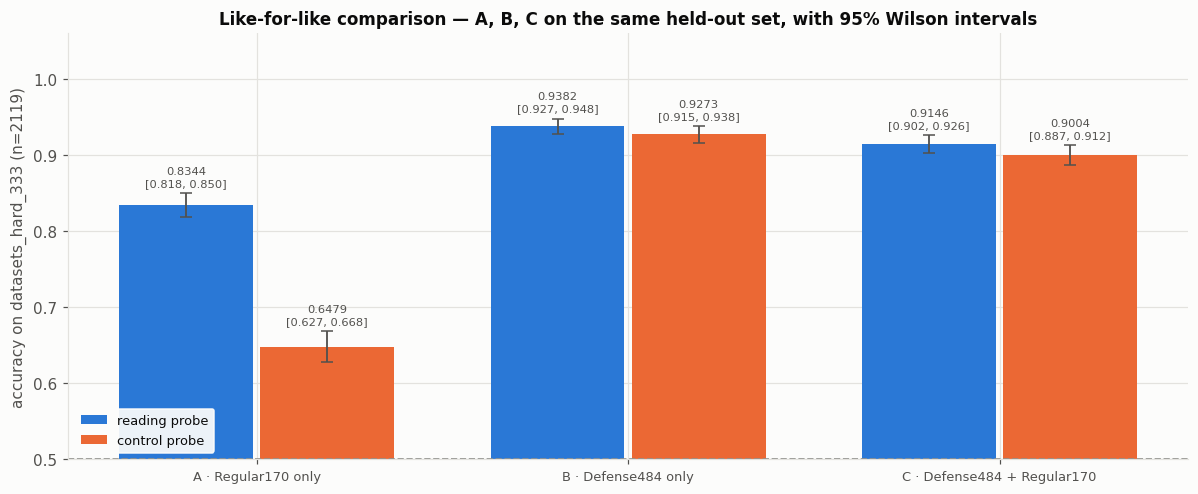

In [36]:
def wilson(p, n, z=1.96):
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h

fig, ax = plt.subplots(figsize=(11, 4.6))
sub = final[final.run.isin(shared)].sort_values(["probe", "run"])
x = np.arange(len(shared))
for k, pt in enumerate(PROBE_TYPES):
    s2 = sub[sub.probe == pt].set_index("run").loc[shared]
    vals = s2["held-out acc"].values
    ns = s2["n_heldout"].values
    lo_hi = np.array([wilson(v, n) for v, n in zip(vals, ns)])
    err = np.vstack([vals - lo_hi[:, 0], lo_hi[:, 1] - vals])
    b = ax.bar(x + (k - 0.5) * 0.38, vals, 0.36, color=PROBE_COLOR[pt], label=f"{pt} probe",
               yerr=err, capsize=4, error_kw=dict(ecolor=INK_SECOND, lw=1.2))
    for bar, v, (lo, hi) in zip(b, vals, lo_hi):
        ax.annotate(f"{v:.4f}\n[{lo:.3f}, {hi:.3f}]",
                    (bar.get_x() + bar.get_width() / 2, hi), textcoords="offset points",
                    xytext=(0, 5), ha="center", fontsize=7.5, color=INK_SECOND)
SHORT = {sp["id"]: sp["short"] for sp in RUN_SPECS}
ax.set_xticks(x, [f"{r} · {SHORT[r]}" for r in shared], fontsize=8.5)
ax.set_ylim(0.5, 1.06)
ax.axhline(0.5, color=INK_MUTED, linestyle="--", linewidth=1.1)
ax.set_ylabel("accuracy on datasets_hard_333 (n=2119)")
ax.set_title("Like-for-like comparison — A, B, C on the same held-out set, with 95% Wilson intervals")
ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()

In [37]:
print("=" * 78)
print("KEY NUMBERS (auto-generated from the artifacts above)")
print("=" * 78)
for pt in PROBE_TYPES:
    print(f"\n[{pt} probe]")
    for rid in RUN_IDS:
        r = final[(final.run == rid) & (final.probe == pt)].iloc[0]
        print(f"  {rid} · {dict((s['id'], s['short']) for s in RUN_SPECS)[rid]:<38} "
              f"pool={r['training pool']:>5}  L{r['best layer']:<2}  "
              f"sel={r['selection acc']:.4f}  heldout={r['held-out acc']:.4f} "
              f"({r['held-out set']}, n={r['n_heldout']})  AUC={r['AUC']:.4f}  ECE={r['ECE']:.4f}")
best_read = final[(final.probe == "reading") & (final.run.isin(shared))].iloc[0]
best_ctrl = final[(final.probe == "control") & (final.run.isin(shared))].iloc[0]
print(f"\nBest on datasets_hard_333 — reading: run {best_read['run']} "
      f"({best_read['held-out acc']:.4f}); control: run {best_ctrl['run']} ({best_ctrl['held-out acc']:.4f})")

KEY NUMBERS (auto-generated from the artifacts above)

[reading probe]
  A · Regular170 only                        pool=  333  L31  sel=0.9368  heldout=0.8344 (hard_333, n=2119)  AUC=0.9127  ECE=0.1316
  B · Defense484 only                        pool= 2880  L25  sel=0.9983  heldout=0.9382 (hard_333, n=2119)  AUC=0.9651  ECE=0.0337
  C · Defense484 + Regular170                pool= 3381  L36  sel=0.9616  heldout=0.9146 (hard_333, n=2119)  AUC=0.9647  ECE=0.0740
  D · Defense484 + Regular170 + JustHard267  pool= 5087  L36  sel=0.9509  heldout=0.9419 (ardulous_66, n=413)  AUC=0.9613  ECE=0.0514

[control probe]
  A · Regular170 only                        pool=  333  L18  sel=0.8375  heldout=0.6479 (hard_333, n=2119)  AUC=0.6729  ECE=0.0729
  B · Defense484 only                        pool= 2880  L10  sel=0.9965  heldout=0.9273 (hard_333, n=2119)  AUC=0.9549  ECE=0.1312
  C · Defense484 + Regular170                pool= 3381  L31  sel=0.9631  heldout=0.9004 (hard_333, n=2119)  AUC=0.957

---
# 11. What the four runs actually say

Every number below is printed by the cells above; nothing here is asserted from
outside the artifacts.

### On the one comparable axis (`datasets_hard_333`, n = 2119)

| | reading | control |
|---|---|---|
| **B** — defense_484 only (2880) | **0.9382** [0.927, 0.948] | **0.9273** [0.915, 0.938] |
| **C** — + regular_170 (3381) | 0.9146 [0.902, 0.926] | 0.9004 [0.887, 0.912] |
| **A** — regular_170 only (333) | 0.8344 [0.818, 0.850] | 0.6479 [0.627, 0.668] |

1. **B is the strongest shipped checkpoint on the shared held-out set, for both
   probe types**, and B vs C is a real difference, not sampling noise — the 95%
   Wilson intervals do not overlap.
2. **Adding `regular_gullibility_170` to `defense_484` made held-out accuracy
   worse** (−2.4 pts reading, −2.7 pts control), despite a larger pool. Two
   things change at once in that step, and the analysis separates them:
   * *Ranking quality barely moved*: AUC 0.9651 → 0.9647 (reading), 0.9549 →
     0.9578 (control). The high unit orders conversations about as well in C as
     in B.
   * *Decision placement moved a lot*: C's best single-unit threshold is 0.73
     (reading) / 0.77 (control) versus B's 0.36 / 0.54, and retuning it recovers
     +0.024 / +0.016 — bringing C to 0.9382 / 0.9160, i.e. essentially back to
     B's shipped accuracy. C's per-class metrics show the same thing from the
     other side: `high` recall 0.987 against `low` recall 0.840.
   So the C regression is dominated by a biased decision boundary, not by a
   worse feature. That is a calibration/threshold problem, and it is fixable
   without retraining.
3. **The 333-conversation `regular_170` set is not enough on its own.** A's
   reading probe still transfers usefully (0.834, AUC 0.913), but A's *control*
   probe is close to useless off-distribution: 0.648 accuracy, AUC 0.673, and a
   19-point collapse from its own selection score (0.838 → 0.648). Whatever the control probe
   latched onto at layer 18 on 333 examples does not exist in `hard_333`.
4. **The reading probe beats the control probe in every run** on the shared set
   (+1.1 pts for B, +1.4 for C, +18.6 for A). The appended
   `" I think the gullibility of this user is"` prompt makes the attribute much
   easier to read out, and it makes the read-out far more robust to small
   training sets. Since steering operates on the *control* position, this gap is
   the number that matters for downstream causality tests, not the reading
   probe's headline.

### Where the signal lives

5. **Depth**: B peaks early (reading L25, control L10) and has 33/35 layers
   above 0.90 selection accuracy — on `defense_484` the attribute is linearly
   available almost everywhere past the first few blocks, and the exact layer
   choice is nearly free (top-10 spread 0.000). A is the opposite: only 5 layers
   (reading) / 0 (control) clear 0.90, and its top-10 spread is 0.055, so its
   layer pick is doing real work and is correspondingly fragile.
6. **Direction geometry**: at matched layers, B, C and D learn nearly the *same*
   direction — cosine 0.75–1.0 through the early and middle stack, decaying to
   ≈0.5–0.7 at the deepest layers for the control probe — while **A's direction
   is close to orthogonal to all of them** (≈0.0–0.4, and essentially 0 for
   A ↔ B on the control probe past layer 5). More data did not rotate the feature; it recovered a
   different one than the small set found. The 8×8 "own best layer" matrix looks
   mostly empty for the same reason a layer-25 vector and a layer-36 vector are
   unrelated — cross-layer cosines are not meaningful, which is why the
   per-layer chart is the one to read.
7. **The two read-out positions are not redundant.** For A they disagree
   constantly (only 60.5% of conversations are right under both; score
   correlation 0.558); by D they have converged (93.7% both correct, correlation
   0.976).

### Errors

8. **Difficulty is mostly a property of the conversation, not the run.** Of the
   2119 shared held-out conversations, 80 (3.8%) are wrong for all three reading
   probes and 1711 (80.7%) are right for all three; the error sets overlap only
   at Jaccard 0.27–0.39, so each run also has its own private failures.
9. **The hardest topics are consistent**: `statistics`, `logical_falsehood`,
   `sociology`, `myths_and_fairytales` and `health` sit at the bottom for every
   run, while `misinformation`, `education`, `religion` and `science` are at or
   near ceiling. That pattern is a property of the generated data as much as of
   the probes and is worth eyeballing in the raw conversations before treating
   the low-accuracy topics as a probe weakness.
10. **Calibration ranks differently from accuracy.** B's reading probe is both
    the most accurate and the best calibrated (ECE 0.034), but B's *control*
    probe is the worst-calibrated checkpoint in the comparable set (ECE 0.131,
    a hair worse than A's reading probe at 0.132) despite being the second most
    accurate on `hard_333` — its scores should not be read as probabilities.

### On run D

11. D looks best in absolute terms (0.9419 reading / 0.9516 control) but it was
    scored on `datasets_ardulous_66` — a different, five-times-smaller dataset —
    while its training pool contains `datasets_justhard_267`, a sibling of the
    `hard_333` set the others were scored on. **Nothing in this notebook
    establishes that D is better than B.** It is the only run whose held-out
    number is not directly comparable, and it is also the run with the strongest
    reason to expect an optimistic held-out number.

## Limitations, and the one experiment that would settle it

* **The comparison is incomplete by construction.** Four probes were each
  evaluated on one dataset, and not the same one. The clean fix is a full
  cross-evaluation: every checkpoint on every held-out set. That needs GPU
  activations (the model must be re-run over each dataset), which is why it is
  not done inline here, but the existing scripts already support it:

  ```bash
  conda activate talktuner-gpu
  for ckpt in probe_checkpoints.withRegularGullibility/reading_probe/regular_gullibility_170_custom_split \
              probe_checkpoints.withDefense484Only/reading_probe \
              probe_checkpoints.withDefense484andRegular170/reading_probe \
              probe_checkpoints.withDefense484Regular170JustHard267/reading_probe; do
    for test in datasets_hard_333 datasets_ardulous_66; do
      python src/test_reading_probe.py --checkpoint_dir "$ckpt" --test_dirs "$test" \
             --output_dir "$ckpt/eval_$(basename $test)"
    done
  done
  # …and the same loop with test_control_probe.py over the control_probe dirs.
  ```

  Until that runs, "which training mix generalizes best" is answered only for
  A/B/C on `hard_333`.
* **Selection accuracy is not a held-out number** anywhere in this notebook: it
  is a max over 41 layers × 50 epochs on the split that chose the layer, and for
  C and D it is a 3-way accuracy. It is included to show training behaviour, not
  to rank runs.
* **`train.sh` notes a known confound** ("sequential nature of conversation
  because of prompt optimisation", temporarily worked around with a k-fold
  split). If conversations generated from the same source question are split
  across train and selection, the selection accuracies here are inflated — which
  would explain why B reaches 0.998 on its own split but 0.938 on `hard_333`.
  Held-out numbers on a *separate dataset* are not affected by that confound.
* **`datasets_regular_gullibility_170` contains a `medium` class** that only C
  and D train on and no held-out set contains, so those two heads carry a unit
  the evaluation always masks. Whether the `medium` examples help or hurt is not
  separable from the other differences in this data.
* **Per-example scores are σ(high) only.** The low unit is not recorded in the
  eval CSVs, so ROC, calibration and the threshold sweep describe the high unit
  rather than the exact deployed argmax rule. Writing both units into
  `_write_score_report` would close that gap cheaply.